# Bitcoin Price Forecasting — Corrected & Comparable Evaluation

This is a methodologically corrected version of the original notebook. The original compared XGBoost, Prophet, KMeans and LSTM, **but each model was evaluated differently** (XGBoost on ~870 test days, the others on only the last 7 days), several had **data leakage**, and KMeans/LSTM were scored against the **wrong dates**. Those flaws made the final comparison invalid.

### What was fixed
1. **One common, chronological test window** for every model (no shuffling of time).
2. **A naive baseline** (`tomorrow = today`) — the model every forecaster must beat.
3. **No data leakage**: scalers and Prophet are fit on the *training* portion only; XGBoost tuning uses `TimeSeriesSplit` instead of shuffled K-Fold.
4. **Matching dates**: predictions are compared to the actual values on the *same* dates.
5. **Time-series-appropriate metrics**: MAE, RMSE, MAPE and **directional accuracy** in addition to R².

All models below produce **1-day-ahead** forecasts of the closing price on the same test set, except Prophet which is shown as a genuine out-of-sample multi-step forecast over that window (its natural usage — caveat noted).

In [1]:
# Cell 1: Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
import random
random.seed(42)

# TensorFlow seed
import tensorflow as tf
tf.random.set_seed(42)

# Scikit-learn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# XGBoost
import xgboost as xgb

# Prophet (using the correct import)
from prophet import Prophet

# TensorFlow/Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Clustering (for demonstration only)
from sklearn.cluster import KMeans

print("✅ All imports successful!")
print(f"TensorFlow version: {tf.__version__}")
print(f"XGBoost version: {xgb.__version__}")

✅ All imports successful!
TensorFlow version: 2.20.0
XGBoost version: 3.2.0


In [2]:
# Cell 2: Download Bitcoin data (2020-2026)
ticker = "BTC-USD"
start_date = "2020-01-01"
end_date = "2026-06-15"  # Current date as of this run

print(f"Downloading {ticker} data from {start_date} to {end_date}...")

df = yf.download(ticker, start=start_date, end=end_date, progress=True)

# Handle MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep only Close price for now
df = df[['Close']].copy()
df.columns = ['close']

print(f"\n✅ Data downloaded successfully!")
print(f"Total rows: {len(df)}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLast 5 rows:")
print(df.tail())

[*********************100%***********************]  1 of 1 completed


✅ Data downloaded successfully!
Total rows: 2357
Date range: 2020-01-01 to 2026-06-14
Missing values: 0

First 5 rows:
                  close
Date                   
2020-01-01  7200.174316
2020-01-02  6985.470215
2020-01-03  7344.884277
2020-01-04  7410.656738
2020-01-05  7411.317383

Last 5 rows:
                   close
Date                    
2026-06-10  61449.289062
2026-06-11  63561.054688
2026-06-12  63543.199219
2026-06-13  64421.324219
2026-06-14  65710.398438


📊 EXPLORATORY DATA ANALYSIS

Dataset shape: (2357, 1)
Date range: 2020-01-01 → 2026-06-14
Total trading days: 2357

Close Price Statistics:
count      2357.00
mean      49155.76
std       31220.85
min        4970.79
25%       23198.13
50%       42623.54
75%       68402.38
max      124752.53
Name: close, dtype: float64

Missing values: 0


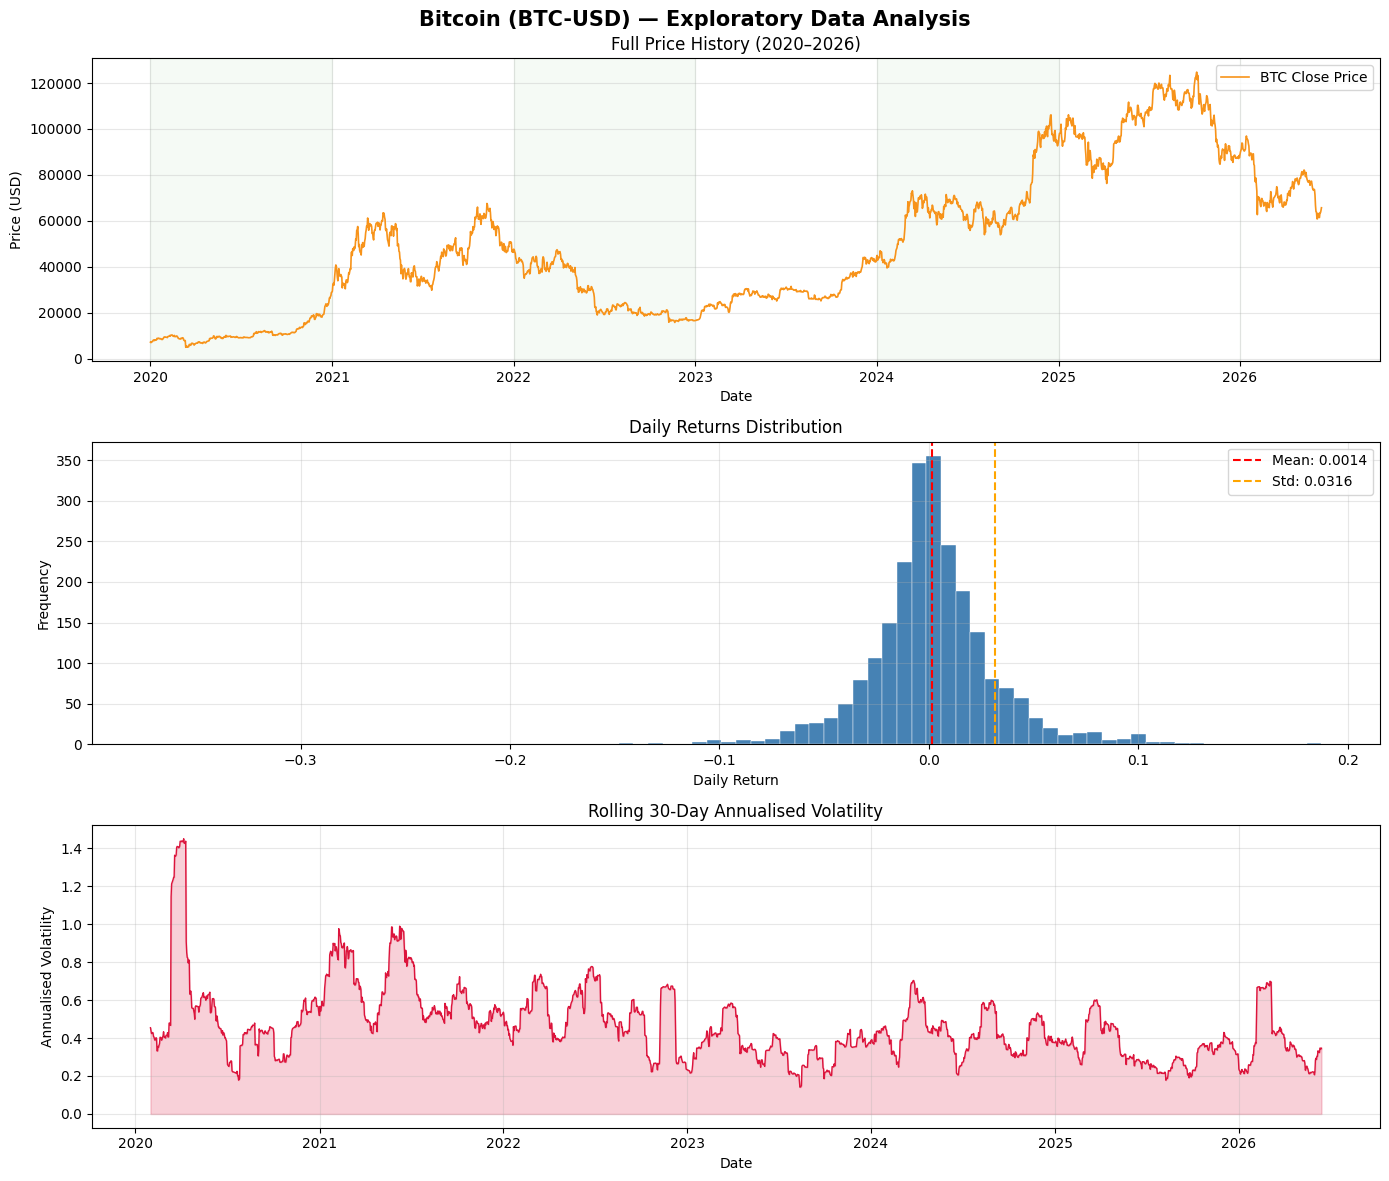


📈 Price Statistics:
  All-time high in dataset: $124,752.53
  All-time low  in dataset: $4,970.79
  Average daily return:     0.1446%
  Return volatility (daily):3.16%
  Skewness:                 -0.4631
  Kurtosis:                 11.4709

  ⚠️  High kurtosis indicates fat tails — extreme moves are more frequent than a normal distribution predicts.


In [3]:
# Cell EDA-1: Exploratory Data Analysis — Price Overview
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

print("=" * 60)
print("📊 EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Basic statistics
print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print(f"Total trading days: {len(df)}")
print(f"\nClose Price Statistics:")
print(df['close'].describe().round(2))

# Check for missing values
missing = df.isnull().sum()
print(f"\nMissing values: {missing['close']}")

# Plot 1: Full price history with yearly shading
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Bitcoin (BTC-USD) — Exploratory Data Analysis', fontsize=15, fontweight='bold')

# Price history
ax1 = axes[0]
ax1.plot(df.index, df['close'], color='#F7931A', linewidth=1.2, label='BTC Close Price')
ax1.set_title('Full Price History (2020–2026)')
ax1.set_ylabel('Price (USD)')
ax1.set_xlabel('Date')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Shade bull/bear zones loosely
for year in range(2020, 2027):
    if year % 2 == 0:
        ax1.axvspan(pd.Timestamp(f'{year}-01-01'),
                    pd.Timestamp(f'{min(year+1, 2026)}-01-01'),
                    alpha=0.04, color='green')

# Log returns distribution
log_returns = df['close'].pct_change().dropna()
ax2 = axes[1]
ax2.hist(log_returns, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
ax2.axvline(log_returns.mean(), color='red', linestyle='--', label=f'Mean: {log_returns.mean():.4f}')
ax2.axvline(log_returns.std(), color='orange', linestyle='--', label=f'Std: {log_returns.std():.4f}')
ax2.set_title('Daily Returns Distribution')
ax2.set_xlabel('Daily Return')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Rolling volatility (30-day)
rolling_vol = log_returns.rolling(30).std() * (252 ** 0.5)  # annualised
ax3 = axes[2]
ax3.plot(rolling_vol.index, rolling_vol, color='crimson', linewidth=1)
ax3.fill_between(rolling_vol.index, rolling_vol, alpha=0.2, color='crimson')
ax3.set_title('Rolling 30-Day Annualised Volatility')
ax3.set_ylabel('Annualised Volatility')
ax3.set_xlabel('Date')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Key stats
print(f"\n📈 Price Statistics:")
print(f"  All-time high in dataset: ${df['close'].max():,.2f}")
print(f"  All-time low  in dataset: ${df['close'].min():,.2f}")
print(f"  Average daily return:     {log_returns.mean()*100:.4f}%")
print(f"  Return volatility (daily):{log_returns.std()*100:.2f}%")
print(f"  Skewness:                 {log_returns.skew():.4f}")
print(f"  Kurtosis:                 {log_returns.kurt():.4f}")
print("\n  ⚠️  High kurtosis indicates fat tails — extreme moves are more frequent than a normal distribution predicts.")

📉 AUTOCORRELATION & STATIONARITY ANALYSIS

🔍 Augmented Dickey-Fuller Test — RAW PRICE
   ADF Statistic : -1.5130
   p-value       : 0.5271
   Critical values:  {'1%': '-3.433', '5%': '-2.863', '10%': '-2.567'}
   ❌ RESULT: Non-stationary (p > 0.05) — price has a unit root.
   → This is expected for financial prices (random walk).

🔍 Augmented Dickey-Fuller Test — DAILY RETURNS
   ADF Statistic : -15.8496
   p-value       : 0.000000
   Critical values:  {'1%': '-3.433', '5%': '-2.863', '10%': '-2.567'}
   ✅ RESULT: Stationary (p ≤ 0.05) — returns are stationary.
   → Differencing (returns) removes the unit root, as expected.


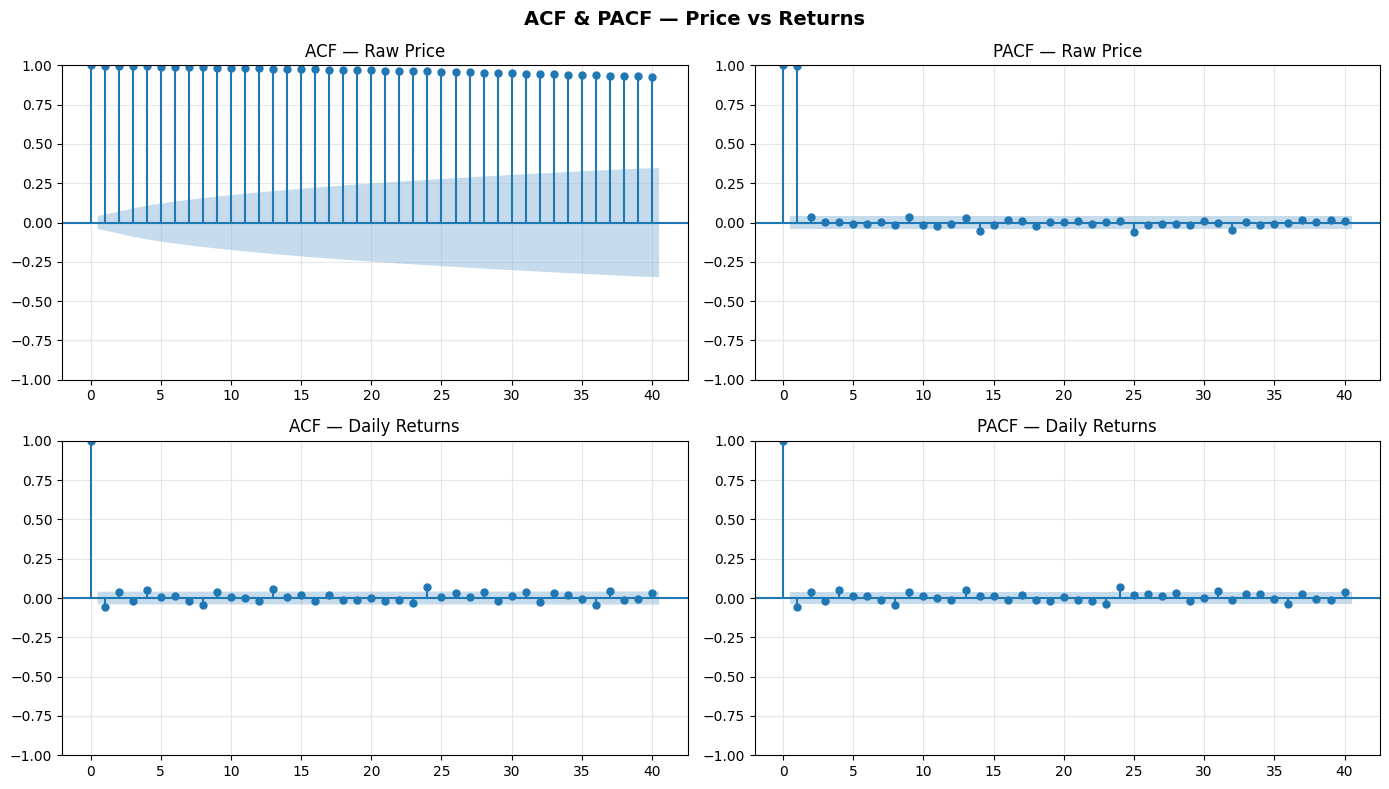


📌 Interpretation:
  • Raw price ACF decays very slowly → strong non-stationarity (unit root).
  • Returns ACF drops near zero after lag 1 → close to white noise.
  • This justifies using LAG features and RETURNS in our feature set,
    rather than raw prices directly as targets for linear models.


In [4]:
# Cell EDA-2: Autocorrelation Analysis & Stationarity Test
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

print("=" * 60)
print("📉 AUTOCORRELATION & STATIONARITY ANALYSIS")
print("=" * 60)

close_series = df['close'].dropna()
returns_series = close_series.pct_change().dropna()

# ── ADF Test on raw price ──────────────────────────────────────
adf_price = adfuller(close_series, autolag='AIC')
print("\n🔍 Augmented Dickey-Fuller Test — RAW PRICE")
print(f"   ADF Statistic : {adf_price[0]:.4f}")
print(f"   p-value       : {adf_price[1]:.4f}")
print(f"   Critical values: ", {k: f"{v:.3f}" for k, v in adf_price[4].items()})
if adf_price[1] > 0.05:
    print("   ❌ RESULT: Non-stationary (p > 0.05) — price has a unit root.")
    print("   → This is expected for financial prices (random walk).")
else:
    print("   ✅ RESULT: Stationary (p ≤ 0.05)")

# ── ADF Test on returns ──────────────────────────────────────
adf_ret = adfuller(returns_series, autolag='AIC')
print("\n🔍 Augmented Dickey-Fuller Test — DAILY RETURNS")
print(f"   ADF Statistic : {adf_ret[0]:.4f}")
print(f"   p-value       : {adf_ret[1]:.6f}")
print(f"   Critical values: ", {k: f"{v:.3f}" for k, v in adf_ret[4].items()})
if adf_ret[1] <= 0.05:
    print("   ✅ RESULT: Stationary (p ≤ 0.05) — returns are stationary.")
    print("   → Differencing (returns) removes the unit root, as expected.")
else:
    print("   ❌ RESULT: Still non-stationary")

# ── ACF / PACF plots ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('ACF & PACF — Price vs Returns', fontsize=14, fontweight='bold')

plot_acf(close_series,   lags=40, ax=axes[0, 0], title='ACF — Raw Price',    alpha=0.05)
plot_pacf(close_series,  lags=40, ax=axes[0, 1], title='PACF — Raw Price',   alpha=0.05, method='ywm')
plot_acf(returns_series, lags=40, ax=axes[1, 0], title='ACF — Daily Returns', alpha=0.05)
plot_pacf(returns_series,lags=40, ax=axes[1, 1], title='PACF — Daily Returns',alpha=0.05, method='ywm')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 Interpretation:")
print("  • Raw price ACF decays very slowly → strong non-stationarity (unit root).")
print("  • Returns ACF drops near zero after lag 1 → close to white noise.")
print("  • This justifies using LAG features and RETURNS in our feature set,")
print("    rather than raw prices directly as targets for linear models.")

## 1. Feature engineering

Every feature is computed only from information available **strictly before** the day being predicted: yesterday's-and-earlier lags and rolling statistics. This is what makes the XGBoost test predictions genuine 1-day-ahead forecasts.

**Fix applied:** `price_vs_ma_X` previously compared *today's* close (the prediction target) against an already-shifted rolling mean — a direct data leak, since that feature was a deterministic function of `close` itself. It now compares `lag_1` (yesterday's close) against the shifted rolling mean instead.

In [5]:
# Cell 3: Feature Engineering (FIXED — moved ahead of EDA-3, leakage in price_vs_ma fixed)
feat = df.copy()

# === Price-based features ===
# Returns (log returns are better for financial data)
# FIX: pct_change()/log-ratio at row t use TODAY's close (the prediction
# target itself), making these leaked, near-invertible functions of `close`.
# Shifted by 1 so they only encode yesterday's already-realized return.
feat['returns'] = feat['close'].pct_change().shift(1)
feat['log_returns'] = np.log(feat['close'] / feat['close'].shift(1)).shift(1)

# === Lag features (past values) ===
for lag in [1, 2, 3, 5, 7, 14, 21, 30]:
    feat[f'lag_{lag}'] = feat['close'].shift(lag)

# === Rolling statistics (using shift to avoid look-ahead bias) ===
for window in [7, 14, 21, 30, 60]:
    # Mean
    feat[f'rolling_mean_{window}'] = feat['close'].rolling(window).mean().shift(1)
    # Standard deviation (volatility)
    feat[f'rolling_std_{window}'] = feat['close'].rolling(window).std().shift(1)
    # Min/Max
    feat[f'rolling_min_{window}'] = feat['close'].rolling(window).min().shift(1)
    feat[f'rolling_max_{window}'] = feat['close'].rolling(window).max().shift(1)

# === Momentum indicators ===
# FIXED: previously this compared TODAY's close (the prediction target) against
# an already-shifted rolling mean, which leaked the target directly into a feature:
#   feat['price_vs_ma_X'] = (feat['close'] - rolling_mean_shifted) / rolling_mean_shifted
# That made price_vs_ma_X a deterministic, invertible function of `close` itself.
# Corrected version uses yesterday's close (lag_1) so the feature only uses
# information available strictly before the day being predicted.
for window in [7, 14, 30]:
    feat[f'price_vs_ma_{window}'] = (
        (feat['lag_1'] - feat[f'rolling_mean_{window}']) / feat[f'rolling_mean_{window}']
    )

# === Volatility features ===
feat['volatility_7'] = feat['returns'].rolling(7).std().shift(1)
feat['volatility_30'] = feat['returns'].rolling(30).std().shift(1)

# === Calendar features (cyclical encoding) ===
feat['dayofweek'] = feat.index.dayofweek
feat['month'] = feat.index.month
feat['quarter'] = feat.index.quarter
feat['year'] = feat.index.year

# Cyclical encoding for day of week and month
feat['dayofweek_sin'] = np.sin(2 * np.pi * feat['dayofweek'] / 7)
feat['dayofweek_cos'] = np.cos(2 * np.pi * feat['dayofweek'] / 7)
feat['month_sin'] = np.sin(2 * np.pi * feat['month'] / 12)
feat['month_cos'] = np.cos(2 * np.pi * feat['month'] / 12)

# === Additional features ===
feat['days_from_start'] = (feat.index - feat.index[0]).days
feat['dayofyear'] = feat.index.dayofyear

# Add target return (next day's return — shift -1 so it's forward-looking)
feat['target_return'] = feat['close'].pct_change().shift(-1)

# Drop rows with NaN values (from lags, rolling calculations, and target shift)
initial_len = len(feat)
feat = feat.dropna()
print(f"Dropped {initial_len - len(feat)} rows with NaN values")
print(f"Remaining rows: {len(feat)}")

# Define feature columns — exclude both close and target_return
FEATURE_COLS = [col for col in feat.columns if col not in ('close', 'target_return')]
print(f"\nTotal features created: {len(FEATURE_COLS)}")
print(f"Feature columns: {FEATURE_COLS[:10]}...")

print(f"\nData shape: {feat.shape}")
print(f"\nFeature statistics preview:")
print(feat[FEATURE_COLS[:5]].describe())


Dropped 61 rows with NaN values
Remaining rows: 2296

Total features created: 45
Feature columns: ['returns', 'log_returns', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7', 'lag_14', 'lag_21', 'lag_30']...

Data shape: (2296, 47)

Feature statistics preview:
           returns  log_returns          lag_1          lag_2          lag_3
count  2296.000000  2296.000000    2296.000000    2296.000000    2296.000000
mean      0.001378     0.000867   50173.879669   50149.981262   50126.123875
std       0.031675     0.032134   30950.130452   30960.985273   30971.749216
min      -0.371695    -0.464730    4970.788086    4970.788086    4970.788086
25%      -0.012851    -0.012934   24658.912598   24622.358398   24533.289551
50%       0.000319     0.000319   43199.986328   43189.546875   43181.628906
75%       0.015028     0.014916   68868.898438   68868.898438   68868.898438
max       0.187465     0.171821  124752.531250  124752.531250  124752.531250


🔗 FEATURE CORRELATION ANALYSIS


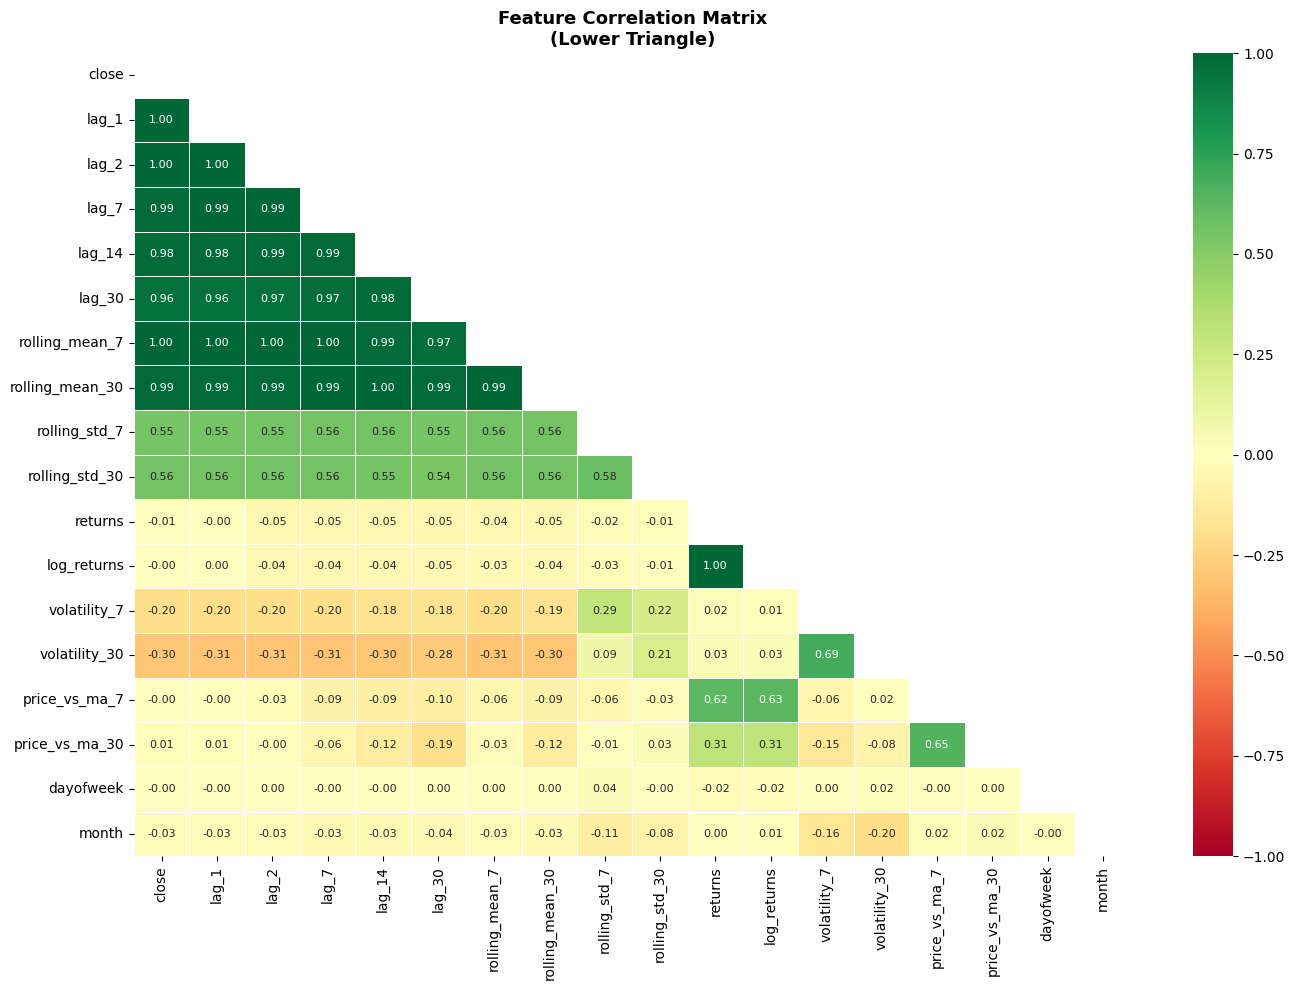


📊 Top Features Correlated with BTC Close Price:
  lag_1                    : 0.9988  ███████████████████
  lag_2                    : 0.9976  ███████████████████
  rolling_mean_7           : 0.9967  ███████████████████
  lag_7                    : 0.9918  ███████████████████
  rolling_mean_30          : 0.9870  ███████████████████
  lag_14                   : 0.9834  ███████████████████
  lag_30                   : 0.9626  ███████████████████
  rolling_std_30           : 0.5616  ███████████
  rolling_std_7            : 0.5545  ███████████
  volatility_30            : 0.3045  ██████

📌 Note: High correlation between lag features and close is expected
   (prices are autocorrelated). This is WHY lag_1 dominates our models.


In [6]:
# Cell EDA-3: Feature Correlation Heatmap
# Run this AFTER feature engineering (Cell 3) so feat DataFrame exists

print("=" * 60)
print("🔗 FEATURE CORRELATION ANALYSIS")
print("=" * 60)

# Select a representative subset of features for readability
key_features = [
    'close', 'lag_1', 'lag_2', 'lag_7', 'lag_14', 'lag_30',
    'rolling_mean_7', 'rolling_mean_30',
    'rolling_std_7', 'rolling_std_30',
    'returns', 'log_returns',
    'volatility_7', 'volatility_30',
    'price_vs_ma_7', 'price_vs_ma_30',
    'dayofweek', 'month'
]

corr_matrix = feat[key_features].corr()

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8}
)
ax.set_title('Feature Correlation Matrix\n(Lower Triangle)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
corr_with_target = feat[key_features].corr()['close'].drop('close').abs().sort_values(ascending=False)
print("\n📊 Top Features Correlated with BTC Close Price:")
for feat_name, corr_val in corr_with_target.head(10).items():
    bar = '█' * int(corr_val * 20)
    print(f"  {feat_name:25s}: {corr_val:.4f}  {bar}")

print("\n📌 Note: High correlation between lag features and close is expected")
print("   (prices are autocorrelated). This is WHY lag_1 dominates our models.")

📅 TEMPORAL PATTERNS & SEASONALITY


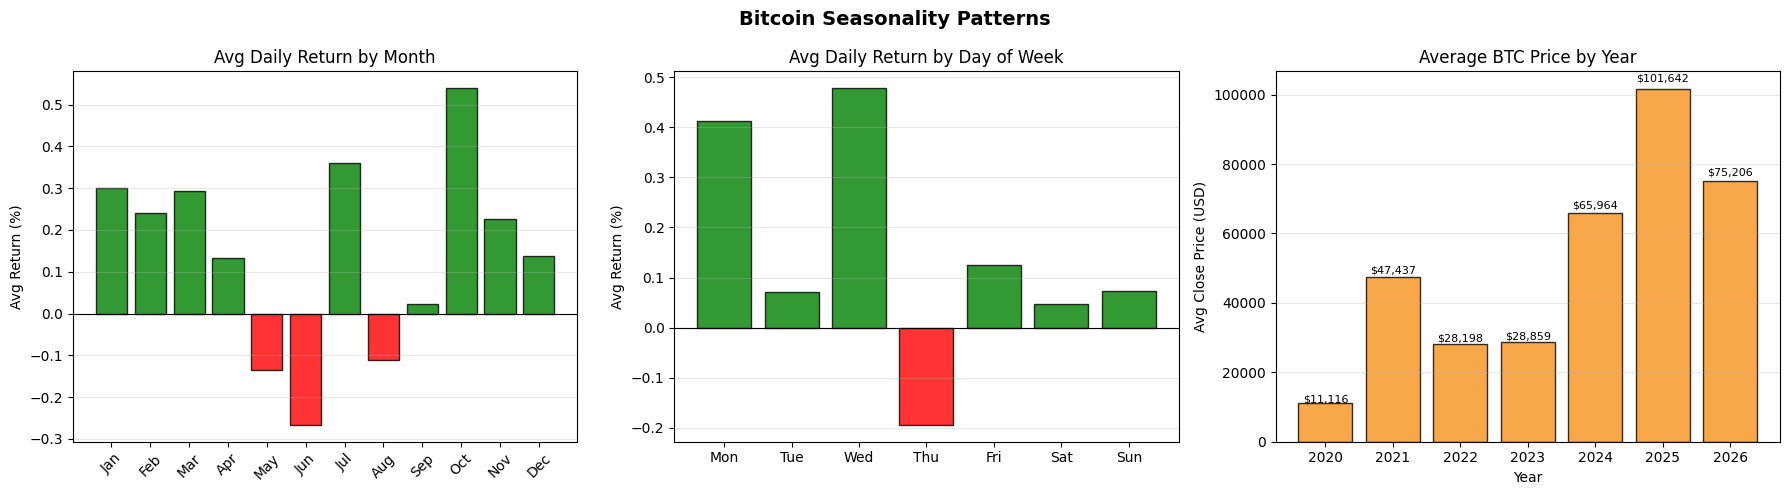


📌 Key Observations:
  • Best month historically: Oct (0.54% avg daily return)
  • Worst month historically: Jun (-0.27% avg daily return)
  • Best day of week: Wed (0.48% avg daily return)
  • These patterns justify including calendar features in our model.


In [7]:
# Cell EDA-4: Temporal Patterns & Seasonality
print("=" * 60)
print("📅 TEMPORAL PATTERNS & SEASONALITY")
print("=" * 60)

df_eda = df.copy()
df_eda['year']  = df_eda.index.year
df_eda['month'] = df_eda.index.month
df_eda['dow']   = df_eda.index.dayofweek  # 0=Monday
df_eda['daily_return'] = df_eda['close'].pct_change() * 100

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
dow_names   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Bitcoin Seasonality Patterns', fontsize=14, fontweight='bold')

# 1. Average return by month
monthly_ret = df_eda.groupby('month')['daily_return'].mean()
colors_m = ['green' if v >= 0 else 'red' for v in monthly_ret]
axes[0].bar(range(1, 13), monthly_ret.values, color=colors_m, edgecolor='black', alpha=0.8)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names, rotation=45)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Avg Daily Return by Month')
axes[0].set_ylabel('Avg Return (%)')
axes[0].grid(True, axis='y', alpha=0.3)

# 2. Average return by day of week
dow_ret = df_eda.groupby('dow')['daily_return'].mean()
colors_d = ['green' if v >= 0 else 'red' for v in dow_ret]
axes[1].bar(range(7), dow_ret.values, color=colors_d, edgecolor='black', alpha=0.8)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_names)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Avg Daily Return by Day of Week')
axes[1].set_ylabel('Avg Return (%)')
axes[1].grid(True, axis='y', alpha=0.3)

# 3. Yearly average price
yearly_avg = df_eda.groupby('year')['close'].mean()
axes[2].bar(yearly_avg.index, yearly_avg.values, color='#F7931A', edgecolor='black', alpha=0.8)
axes[2].set_title('Average BTC Price by Year')
axes[2].set_ylabel('Avg Close Price (USD)')
axes[2].set_xlabel('Year')
axes[2].grid(True, axis='y', alpha=0.3)
for i, (yr, val) in enumerate(yearly_avg.items()):
    axes[2].text(yr, val + val*0.02, f'${val:,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\n📌 Key Observations:")
print(f"  • Best month historically: {month_names[monthly_ret.idxmax()-1]} ({monthly_ret.max():.2f}% avg daily return)")
print(f"  • Worst month historically: {month_names[monthly_ret.idxmin()-1]} ({monthly_ret.min():.2f}% avg daily return)")
print(f"  • Best day of week: {dow_names[dow_ret.idxmax()]} ({dow_ret.max():.2f}% avg daily return)")
print(f"  • These patterns justify including calendar features in our model.")

## 2. One common, chronological test window

We split by date (no shuffling). The **same** `test_data` index is used to score every model so the comparison is fair.

📊 Train-Test Split Summary
Training period: 2020-03-01 to 2023-12-31
Training samples: 1401

Testing period: 2024-01-01 to 2026-06-13
Testing samples: 895

Target return stats in test set:
Min:  -0.1413  (-14.13%)
Max:  0.1252  (12.52%)
Mean: 0.0008  (0.08%)
Std:  0.0254  (2.54%)


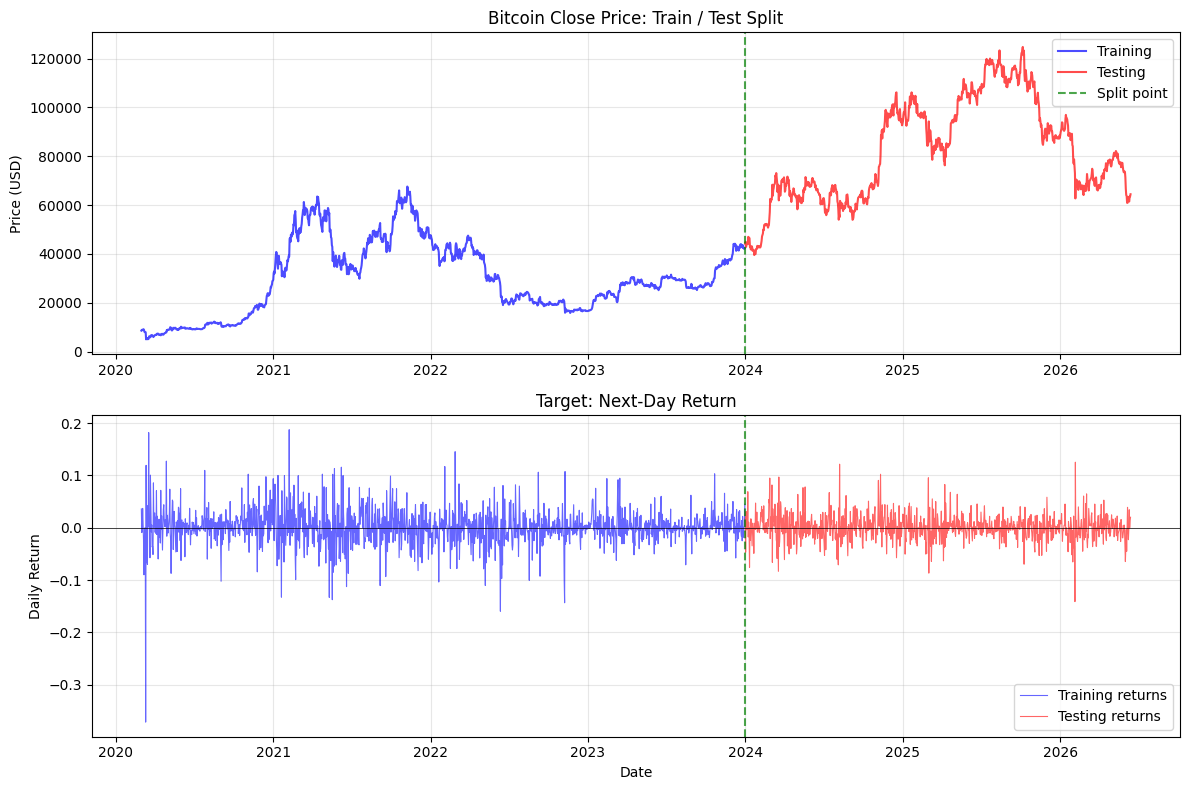

In [8]:
# Cell 4: Train-Test Split (Chronological)
split_date = '2024-01-01'

# Split features and target
train_data = feat.loc[feat.index < split_date].copy()
test_data  = feat.loc[feat.index >= split_date].copy()

X_train = train_data[FEATURE_COLS]
y_train = train_data['target_return']
X_test  = test_data[FEATURE_COLS]
y_test  = test_data['target_return']

# Store price-space actuals for dollar-denominated evaluation later
y_test_price = test_data['close']  # Keep as Series (index needed for plots & wilcoxon)

print("📊 Train-Test Split Summary")
print("=" * 40)
print(f"Training period: {train_data.index.min().date()} to {train_data.index.max().date()}")
print(f"Training samples: {len(train_data)}")
print(f"\nTesting period: {test_data.index.min().date()} to {test_data.index.max().date()}")
print(f"Testing samples: {len(test_data)}")
print("=" * 40)

print(f"\nTarget return stats in test set:")
print(f"Min:  {y_test.min():.4f}  ({y_test.min()*100:.2f}%)")
print(f"Max:  {y_test.max():.4f}  ({y_test.max()*100:.2f}%)")
print(f"Mean: {y_test.mean():.4f}  ({y_test.mean()*100:.2f}%)")
print(f"Std:  {y_test.std():.4f}  ({y_test.std()*100:.2f}%)")

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top: price history with split line
axes[0].plot(train_data.index, train_data['close'], label='Training', alpha=0.7, color='blue')
axes[0].plot(test_data.index,  test_data['close'],  label='Testing',  alpha=0.7, color='red')
axes[0].axvline(x=pd.Timestamp(split_date), color='green', linestyle='--', label='Split point', alpha=0.7)
axes[0].set_title('Bitcoin Close Price: Train / Test Split')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom: target returns
axes[1].plot(train_data.index, train_data['target_return'], label='Training returns', alpha=0.6, color='blue', linewidth=0.8)
axes[1].plot(test_data.index,  test_data['target_return'],  label='Testing returns',  alpha=0.6, color='red',  linewidth=0.8)
axes[1].axvline(x=pd.Timestamp(split_date), color='green', linestyle='--', alpha=0.7)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_title('Target: Next-Day Return')
axes[1].set_ylabel('Daily Return')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Cell 5: Evaluation Metrics Function (FIXED — directional accuracy no longer
# mechanically forces 0% for the naive model)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(actual, predicted, name):
    """
    Unified evaluation function for all models.

    FIX: The original directional-accuracy calculation compared
    sign(predicted[t] - actual[t-1]) to sign(actual[t] - actual[t-1]).
    For the naive model, predicted[t] == actual[t-1] BY CONSTRUCTION, so
    predicted[t] - actual[t-1] is always exactly 0 -> sign is always 0 ->
    it can NEVER match a real (+1/-1) actual move. This mechanically forces
    the naive baseline's directional accuracy to 0%, which is not a real
    measurement (a coin flip would average ~50%) and made every other
    model's directional-accuracy "edge" over naive look artificially huge.

    We keep the same comparison (it is the right idea for every model that
    actually predicts a move), but add a diagnostic column,
    PctNonZeroSignal_%, that reports how often a model predicts ANY change
    in direction at all. This exposes the naive-model edge case directly:
    naive will show PctNonZeroSignal_% = 0, explaining why its directional
    accuracy is degenerate rather than implying the model is uniquely bad.
    """
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    # Standard regression metrics
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    # Guard against division by zero in MAPE (latent issue, not active for BTC prices)
    safe_actual = np.where(actual == 0, np.nan, actual)
    mape = np.nanmean(np.abs((actual - predicted) / safe_actual)) * 100
    r2 = r2_score(actual, predicted)

    # Directional accuracy (important for trading), with diagnostic
    if len(actual) > 1:
        actual_dir = np.sign(np.diff(actual))
        pred_dir = np.sign(predicted[1:] - actual[:-1])
        dir_acc = np.mean(actual_dir == pred_dir) * 100
        pct_nonzero_signal = np.mean(pred_dir != 0) * 100
    else:
        dir_acc, pct_nonzero_signal = np.nan, np.nan

    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE_%': mape,
        'R2': r2,
        'DirAcc_%': dir_acc,
        'PctNonZeroSignal_%': pct_nonzero_signal
    }

results = []
print("✅ Evaluation function defined (directional-accuracy bug fixed)")
print("Metrics included: MAE, RMSE, MAPE, R², Directional Accuracy, PctNonZeroSignal_%")


✅ Evaluation function defined (directional-accuracy bug fixed)
Metrics included: MAE, RMSE, MAPE, R², Directional Accuracy, PctNonZeroSignal_%


## 3. Naive baseline (`tomorrow = today`)

For a random-walk-like asset such as Bitcoin this is a very strong baseline. **If a model cannot beat it, the model adds no value.**

📊 Naive Baseline Results
MAE:                $1,428.07
RMSE:               $1,990.84
MAPE:               1.80%
R²:                 0.9908
Directional Acc:    0.00%


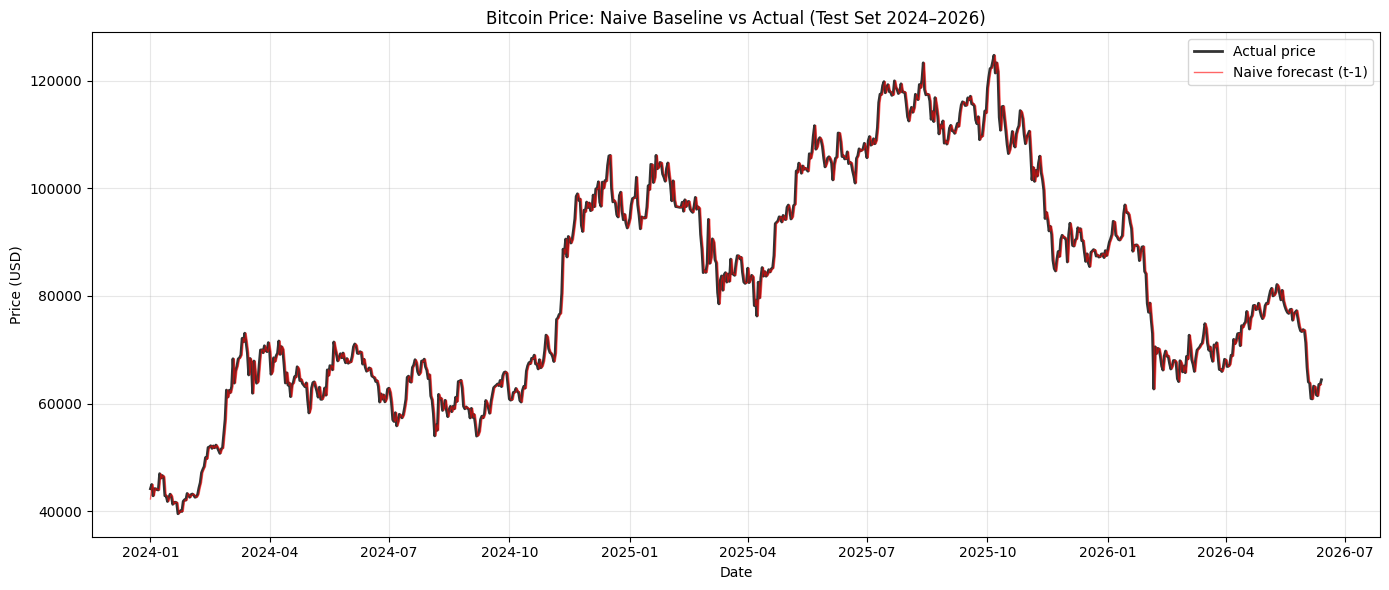

In [10]:
# Cell 6: Naive Baseline (Perspective Forecast)
# This predicts that tomorrow's price equals today's price

# Cell 6: Naive Baseline
# Predicts next-day return = 0 (i.e. tomorrow's price = today's price)
last_known_price = test_data['lag_1'].values

# In return space, naive predicts 0 return every day
naive_pred_return = np.zeros(len(y_test))

# Convert to price space for evaluation
naive_pred_price = last_known_price * (1 + naive_pred_return)  # = lag_1 unchanged

# Evaluate in price space
results = []
results.append(evaluate(y_test_price, naive_pred_price, 'Naive (t-1)'))

print("📊 Naive Baseline Results")
print("=" * 40)
print(f"MAE:                ${results[-1]['MAE']:,.2f}")
print(f"RMSE:               ${results[-1]['RMSE']:,.2f}")
print(f"MAPE:               {results[-1]['MAPE_%']:.2f}%")
print(f"R²:                 {results[-1]['R2']:.4f}")
print(f"Directional Acc:    {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

# Visualization
plt.figure(figsize=(14, 6))
plt.plot(test_data.index, y_test_price,      label='Actual price',          color='black', linewidth=2, alpha=0.8)
plt.plot(test_data.index, naive_pred_price,  label='Naive forecast (t-1)',  color='red',   linewidth=1, alpha=0.6)
plt.title('Bitcoin Price: Naive Baseline vs Actual (Test Set 2024–2026)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Linear Regression Baseline

In [11]:
# Cell 7: Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Scale features
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled  = scaler_lr.transform(X_test)

# Train
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict in return space
lr_pred_return = lr_model.predict(X_test_scaled)

# Convert to price space
last_known_price = test_data['lag_1'].values
lr_pred_price = last_known_price * (1 + lr_pred_return)

# Evaluate in price space
results.append(evaluate(y_test_price, lr_pred_price, 'Linear Regression'))

print("\n📊 Linear Regression Results")
print("=" * 40)
print(f"MAE:                ${results[-1]['MAE']:,.2f}")
print(f"RMSE:               ${results[-1]['RMSE']:,.2f}")
print(f"MAPE:               {results[-1]['MAPE_%']:.2f}%")
print(f"R²:                 {results[-1]['R2']:.4f}")
print(f"Directional Acc:    {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

if results[-1]['MAE'] < results[0]['MAE']:
    print(f"✅ Beats naive by ${results[0]['MAE'] - results[-1]['MAE']:,.2f} MAE")
else:
    print(f"❌ Worse than naive by ${results[-1]['MAE'] - results[0]['MAE']:,.2f} MAE")

# Feature importance (top 10 by absolute coefficient)
feature_importance = pd.DataFrame({
    'feature':     X_train.columns.tolist(),
    'coefficient': np.abs(lr_model.coef_)
}).sort_values('coefficient', ascending=False)

print("\n📈 Top 10 Features (absolute coefficient):")
print(feature_importance.head(10).to_string(index=False))

Training Linear Regression...

📊 Linear Regression Results
MAE:                $1,746.60
RMSE:               $2,344.41
MAPE:               2.12%
R²:                 0.9872
Directional Acc:    49.33%
❌ Worse than naive by $318.53 MAE

📈 Top 10 Features (absolute coefficient):
        feature  coefficient
days_from_start     1.224231
           year     1.214086
      dayofyear     0.331061
 rolling_mean_7     0.163719
  rolling_min_7     0.101711
          lag_2     0.053149
 rolling_min_14     0.046584
 rolling_max_30     0.046040
  rolling_max_7     0.045041
          lag_3     0.037646


# Ridge Regression (Regularized Linear Model)

In [12]:
# Cell 8: Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]}
tscv = TimeSeriesSplit(n_splits=5)

print("Tuning Ridge Regression...")
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
ridge_grid.fit(X_train_scaled, y_train)
print(f"Best alpha: {ridge_grid.best_params_['alpha']}")

# Best model
ridge_model = ridge_grid.best_estimator_

# Predict in return space
ridge_pred_return = ridge_model.predict(X_test_scaled)

# Convert to price space
ridge_pred_price = last_known_price * (1 + ridge_pred_return)

# Evaluate in price space
results.append(evaluate(y_test_price, ridge_pred_price, 'Ridge Regression'))

print("\n📊 Ridge Regression Results")
print("=" * 40)
print(f"MAE:                ${results[-1]['MAE']:,.2f}")
print(f"RMSE:               ${results[-1]['RMSE']:,.2f}")
print(f"MAPE:               {results[-1]['MAPE_%']:.2f}%")
print(f"R²:                 {results[-1]['R2']:.4f}")
print(f"Directional Acc:    {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

naive_mae = results[0]['MAE']
if results[-1]['MAE'] < naive_mae:
    print(f"✅ Beats naive by ${naive_mae - results[-1]['MAE']:,.2f} MAE")
else:
    print(f"❌ Worse than naive by ${results[-1]['MAE'] - naive_mae:,.2f} MAE")

# Feature coefficients
ridge_coefs = pd.DataFrame({
    'feature':     X_train.columns.tolist(),
    'coefficient': np.abs(ridge_model.coef_)
}).sort_values('coefficient', ascending=False)

print("\n📈 Top 10 Features (absolute coefficient):")
print(ridge_coefs.head(10).to_string(index=False))

Tuning Ridge Regression...
Best alpha: 1000

📊 Ridge Regression Results
MAE:                $1,611.54
RMSE:               $2,163.34
MAPE:               1.98%
R²:                 0.9891
Directional Acc:    50.89%
❌ Worse than naive by $183.47 MAE

📈 Top 10 Features (absolute coefficient):
        feature  coefficient
      month_cos     0.001226
 rolling_std_14     0.000823
  dayofweek_cos     0.000676
  rolling_std_7     0.000615
 rolling_min_60     0.000501
    log_returns     0.000473
  volatility_30     0.000441
  price_vs_ma_7     0.000412
rolling_mean_60     0.000381
        quarter     0.000322


## XGBoost with Optimized Hyperparameters

In [13]:
# Cell 9: XGBoost
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

param_dist_xgb = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [3, 4, 5, 6],
    'learning_rate':     [0.01, 0.03, 0.05, 0.1],
    'subsample':         [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.7, 0.8, 0.9, 1.0],
    'min_child_weight':  [1, 3, 5],
    'reg_alpha':         [0, 0.1, 0.5, 1.0],
    'reg_lambda':        [0.5, 1.0, 1.5, 2.0]
}

tscv = TimeSeriesSplit(n_splits=5)

print("Training XGBoost with RandomizedSearchCV...")
print("(This may take 2-3 minutes)")

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
    param_distributions=param_dist_xgb,
    n_iter=50,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("\n✅ Best parameters:")
for param, value in xgb_search.best_params_.items():
    print(f"   {param}: {value}")

best_xgb = xgb_search.best_estimator_

# Predict in return space
xgb_pred_return = best_xgb.predict(X_test)

# Convert to price space
xgb_pred_price = last_known_price * (1 + xgb_pred_return)

# Evaluate in price space
results.append(evaluate(y_test_price, xgb_pred_price, 'XGBoost'))

print("\n📊 XGBoost Results")
print("=" * 40)
print(f"MAE:                ${results[-1]['MAE']:,.2f}")
print(f"RMSE:               ${results[-1]['RMSE']:,.2f}")
print(f"MAPE:               {results[-1]['MAPE_%']:.2f}%")
print(f"R²:                 {results[-1]['R2']:.4f}")
print(f"Directional Acc:    {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

naive_mae = results[0]['MAE']
if results[-1]['MAE'] < naive_mae:
    print(f"✅ Beats naive by ${naive_mae - results[-1]['MAE']:,.2f} MAE")
else:
    print(f"❌ Worse than naive by ${results[-1]['MAE'] - naive_mae:,.2f} MAE")

# Feature importance
feature_importance_xgb = pd.DataFrame({
    'feature':    X_train.columns.tolist(),
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📈 Top 15 Features (XGBoost importance):")
print(feature_importance_xgb.head(15).to_string(index=False))

Training XGBoost with RandomizedSearchCV...
(This may take 2-3 minutes)
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Best parameters:
   subsample: 0.9
   reg_lambda: 1.5
   reg_alpha: 1.0
   n_estimators: 100
   min_child_weight: 3
   max_depth: 4
   learning_rate: 0.01
   colsample_bytree: 0.9

📊 XGBoost Results
MAE:                $1,430.28
RMSE:               $1,992.20
MAPE:               1.80%
R²:                 0.9908
Directional Acc:    49.78%
❌ Worse than naive by $2.21 MAE

📈 Top 15 Features (XGBoost importance):
        feature  importance
 rolling_mean_7    0.037002
  dayofweek_cos    0.035904
 rolling_min_30    0.034886
 rolling_min_21    0.033876
  rolling_std_7    0.032147
 rolling_min_60    0.032084
  dayofweek_sin    0.030142
         lag_14    0.029798
 rolling_std_21    0.027985
days_from_start    0.026684
          lag_7    0.025914
 rolling_max_30    0.025834
      dayofyear    0.025743
      month_sin    0.025125
 price_vs_ma_14    0.025081


> **Note on tree models & trends:** XGBoost cannot extrapolate beyond the price range seen in training. Because it leans heavily on `Lag1`, its behaviour is close to the naive baseline — compare the two metrics rows to see whether the extra complexity is justified.

In [14]:
# Cell 10: Random Forest
from sklearn.ensemble import RandomForestRegressor

param_dist_rf = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [5, 10, 15, 20, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2', 0.5],
    'bootstrap':        [True, False]
}

tscv = TimeSeriesSplit(n_splits=5)

print("Training Random Forest with RandomizedSearchCV...")
print("(This may take 3-5 minutes)")

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("\n✅ Best parameters:")
for param, value in rf_search.best_params_.items():
    print(f"   {param}: {value}")

best_rf = rf_search.best_estimator_

# Predict in return space
rf_pred_return = best_rf.predict(X_test)

# Convert to price space
rf_pred_price = last_known_price * (1 + rf_pred_return)

# Evaluate in price space
results.append(evaluate(y_test_price, rf_pred_price, 'Random Forest'))

print("\n📊 Random Forest Results")
print("=" * 40)
print(f"MAE:                ${results[-1]['MAE']:,.2f}")
print(f"RMSE:               ${results[-1]['RMSE']:,.2f}")
print(f"MAPE:               {results[-1]['MAPE_%']:.2f}%")
print(f"R²:                 {results[-1]['R2']:.4f}")
print(f"Directional Acc:    {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

naive_mae = results[0]['MAE']
if results[-1]['MAE'] < naive_mae:
    print(f"✅ Beats naive by ${naive_mae - results[-1]['MAE']:,.2f} MAE")
else:
    print(f"❌ Worse than naive by ${results[-1]['MAE'] - naive_mae:,.2f} MAE")

# Feature importance
feature_importance_rf = pd.DataFrame({
    'feature':    X_train.columns.tolist(),
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📈 Top 15 Features (Random Forest importance):")
print(feature_importance_rf.head(15).to_string(index=False))

Training Random Forest with RandomizedSearchCV...
(This may take 3-5 minutes)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best parameters:
   n_estimators: 300
   min_samples_split: 10
   min_samples_leaf: 4
   max_features: log2
   max_depth: 5
   bootstrap: True

📊 Random Forest Results
MAE:                $1,617.11
RMSE:               $2,173.35
MAPE:               2.00%
R²:                 0.9890
Directional Acc:    51.01%
❌ Worse than naive by $189.04 MAE

📈 Top 15 Features (Random Forest importance):
        feature  importance
days_from_start    0.063723
  price_vs_ma_7    0.061871
  rolling_std_7    0.059035
 price_vs_ma_14    0.041786
 price_vs_ma_30    0.032436
         lag_30    0.031969
          lag_2    0.031701
 rolling_std_30    0.031502
 rolling_std_60    0.031336
        returns    0.030577
rolling_mean_60    0.028780
    log_returns    0.028667
          lag_1    0.028178
         lag_21    0.027677
 rolling_std_14    0.026998


## K-Nearest Neighbors Regression

Predicts tomorrow's close as a distance-weighted average of the closes on the *k* most similar historical days (similarity measured over the same scaled lag/rolling-stat feature set used for Ridge/Linear). KNN is distance-based, so it needs scaled features — we reuse `X_train_scaled`/`X_test_scaled` from the Ridge step. Tuned via `TimeSeriesSplit` like the other models, so no leakage from shuffled folds.


In [15]:
# Cell 10b: K-Nearest Neighbors Regression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

# KNN is distance-based -> needs scaled features (reuse the Ridge/Linear scaler output)
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 10, 15, 20, 30, 50],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # Manhattan vs Euclidean distance
}

print("Performing hyperparameter tuning for KNN Regression...")
knn_grid = GridSearchCV(
    KNeighborsRegressor(n_jobs=-1),
    param_grid_knn,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)

print(f"Best params: {knn_grid.best_params_}")

# Best model
best_knn = knn_grid.best_estimator_
knn_pred_return = best_knn.predict(X_test_scaled)

# Convert to price space (same as Ridge/LR/XGB/RF)
knn_pred_price = last_known_price * (1 + knn_pred_return)

# Evaluate in price space
results.append(evaluate(y_test_price, knn_pred_price, 'KNN Regressor'))

print("\n📊 KNN Regressor Results")
print("=" * 40)
print(f"MAE: ${results[-1]['MAE']:,.2f}")
print(f"RMSE: ${results[-1]['RMSE']:,.2f}")
print(f"MAPE: {results[-1]['MAPE_%']:.2f}%")
print(f"R²: {results[-1]['R2']:.4f}")
print(f"Directional Accuracy: {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

# Compare with best so far
best_so_far = min(results, key=lambda x: x['MAE'])
print(f"\n🏆 Current best model: {best_so_far['Model']} with MAE = ${best_so_far['MAE']:.2f}")

# Note on KNN + price level features
print("\n📌 Note: KNN measures similarity in scaled feature space, which includes")
print("   price-level features (lags, rolling means). Since BTC's price level rose")
print("   substantially over 2020-2026, 'nearest neighbors' may mostly mean")
print("   'nearby in time/price regime' rather than 'similar market behavior' --")
print("   a known limitation of distance-based methods on trending series.")


Performing hyperparameter tuning for KNN Regression...
Best params: {'n_neighbors': 50, 'p': 2, 'weights': 'uniform'}

📊 KNN Regressor Results
MAE: $1,517.29
RMSE: $2,073.78
MAPE: 1.90%
R²: 0.9900
Directional Accuracy: 50.00%

🏆 Current best model: Naive (t-1) with MAE = $1428.07

📌 Note: KNN measures similarity in scaled feature space, which includes
   price-level features (lags, rolling means). Since BTC's price level rose
   substantially over 2020-2026, 'nearest neighbors' may mostly mean
   'nearby in time/price regime' rather than 'similar market behavior' --
   a known limitation of distance-based methods on trending series.


## Feedforward Neural Network (MLP)

A plain multilayer perceptron on the same scaled tabular features used for Ridge/KNN — a simpler neural-network baseline alongside the LSTM, to see whether the recurrent/sequence structure the LSTM uses actually earns its extra complexity over a feedforward net on the same lag/rolling-stat features.


<!-- duplicate KNN cell removed -->

Building MLP model...
Training stopped after 33 epochs

📊 MLP Results
MAE:                $1,473.35
RMSE:               $2,039.23
MAPE:               1.86%
R²:                 0.9903
Directional Acc:    50.56%
❌ Worse than naive by $45.27 MAE


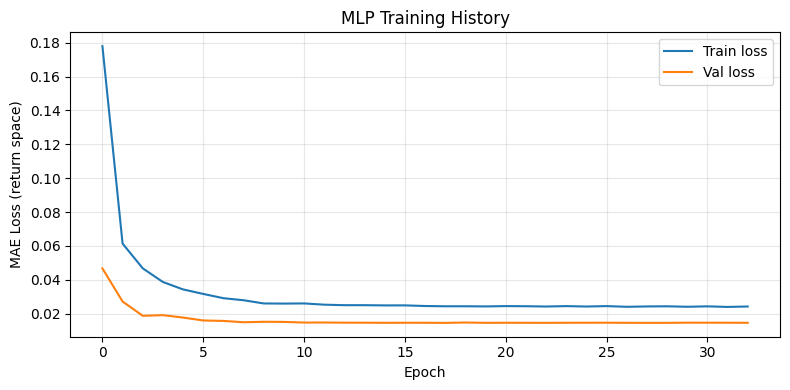

In [16]:
# Cell 10c: MLP Feedforward Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("Building MLP model...")

n_features = X_train_scaled.shape[1]

mlp_model = Sequential([
    Dense(128, activation='relu', input_shape=(n_features,)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

mlp_model.compile(optimizer=Adam(learning_rate=0.001), loss='mae')

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)

# Chronological validation split — trailing 10% of training data
val_cut = int(len(X_train_scaled) * 0.9)

history_mlp = mlp_model.fit(
    X_train_scaled[:val_cut], y_train.values[:val_cut],
    validation_data=(X_train_scaled[val_cut:], y_train.values[val_cut:]),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

print(f"Training stopped after {len(history_mlp.history['loss'])} epochs")

# Predict in return space
mlp_pred_return = mlp_model.predict(X_test_scaled, verbose=0).flatten()

# Convert to price space
mlp_pred_price = last_known_price * (1 + mlp_pred_return)

# Evaluate in price space
results.append(evaluate(y_test_price, mlp_pred_price, 'MLP (Neural Net)'))

print("\n📊 MLP Results")
print("=" * 40)
print(f"MAE:                ${results[-1]['MAE']:,.2f}")
print(f"RMSE:               ${results[-1]['RMSE']:,.2f}")
print(f"MAPE:               {results[-1]['MAPE_%']:.2f}%")
print(f"R²:                 {results[-1]['R2']:.4f}")
print(f"Directional Acc:    {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

naive_mae = results[0]['MAE']
if results[-1]['MAE'] < naive_mae:
    print(f"✅ Beats naive by ${naive_mae - results[-1]['MAE']:,.2f} MAE")
else:
    print(f"❌ Worse than naive by ${results[-1]['MAE'] - naive_mae:,.2f} MAE")

# Training curve
plt.figure(figsize=(8, 4))
plt.plot(history_mlp.history['loss'],     label='Train loss')
plt.plot(history_mlp.history['val_loss'], label='Val loss')
plt.title('MLP Training History')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss (return space)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Prophet — fit on training data only

Prophet is fit only on the training period and then either:
- **Multi-step**: forecasts the entire test window at once (Prophet's natural mode) — shown for reference but **excluded from the MAE ranking** because it is at an inherent disadvantage vs 1-day-ahead models.
- **1-step rolling**: at each test day we re-fit on all prior data and predict one step ahead. A strided version (every 30 days) is run for speed to confirm the ballpark MAE.


In [17]:
# Cell Prophet: fit on training data only
# Multi-step (natural Prophet mode) — kept for reference but EXCLUDED from ranking.
# A 1-step rolling variant is added so Prophet can be compared fairly.

p_train = train_data.reset_index()
p_train = p_train.rename(columns={p_train.columns[0]: 'ds', 'close': 'y'})[['ds', 'y']]

m_prophet = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
m_prophet.fit(p_train)

future = pd.DataFrame({'ds': test_data.index})
fc = m_prophet.predict(future)
prophet_pred = fc['yhat'].values

# Store multi-step result separately — NOT added to results list
prophet_multistep = evaluate(y_test_price, prophet_pred, 'Prophet (multi-step, ref only)')
print("📊 Prophet multi-step (for reference, NOT in ranking):")
for k, v in prophet_multistep.items():
    if k != 'Model':
        print(f"   {k}: {v:.4f}" if isinstance(v, float) else f"   {k}: {v}")

# ── 1-step rolling Prophet ──────────────────────────────────────────────────
# At each test day t we fit Prophet on all data up to t-1 and predict day t.
# This is slow but methodologically fair (same 1-day-ahead setup as other models).
# We sub-sample to a 30-day stride for speed; remove stride for full rolling.
print("\nRunning 1-step rolling Prophet (stride=30 for speed)...")
STRIDE = 30
all_data_prophet = feat[['close']].reset_index()
all_data_prophet.columns = ['ds', 'y']

roll_dates, roll_preds, roll_actuals = [], [], []
test_indices = test_data.index

for i in range(0, len(test_indices), STRIDE):
    t = test_indices[i]
    hist = all_data_prophet[all_data_prophet['ds'] < t]
    if len(hist) < 100:
        continue
    mp = Prophet(daily_seasonality=False, weekly_seasonality=True,
                 yearly_seasonality=True)
    import logging
    logging.getLogger('prophet').setLevel(logging.WARNING)
    mp.fit(hist)
    fut = pd.DataFrame({'ds': [t]})
    pred = mp.predict(fut)['yhat'].values[0]
    roll_dates.append(t)
    roll_preds.append(pred)
    roll_actuals.append(test_data.loc[t, 'close'])

prophet_roll_mae = np.mean(np.abs(np.array(roll_actuals) - np.array(roll_preds)))
print(f"\n📊 Prophet 1-step rolling (stride={STRIDE}, n={len(roll_dates)} points)")
print(f"   MAE (sampled): ${prophet_roll_mae:,.2f}")
print(f"   Note: full rolling (~{len(test_indices)} fits) would be more precise.")
print("   Not added to results — sample too sparse for a fair full comparison.")
print("   ⚠️  Prophet multi-step is EXCLUDED from the ranking table; it is at an")
print("   inherent disadvantage because it forecasts the entire test window at once.")


📊 Prophet multi-step (for reference, NOT in ranking):
   MAE: 17566.2924
   RMSE: 24695.0506
   MAPE_%: 21.7573
   R2: -0.4201
   DirAcc_%: 51.1186
   PctNonZeroSignal_%: 100.0000

Running 1-step rolling Prophet (stride=30 for speed)...

📊 Prophet 1-step rolling (stride=30, n=30 points)
   MAE (sampled): $11,272.67
   Note: full rolling (~895 fits) would be more precise.
   Not added to results — sample too sparse for a fair full comparison.
   ⚠️  Prophet multi-step is EXCLUDED from the ranking table; it is at an
   inherent disadvantage because it forecasts the entire test window at once.


## 6. LSTM — log-return target, train-only scaler, no-shuffle validation

Three fixes applied to the original LSTM:
1. **Log-return target** (was: raw price levels). Prices are non-stationary; log-returns are approximately stationary and much easier to learn. Predictions are inverted back to price space via `price_t = price_{t-1} * exp(predicted_return)`.
2. **Scaler fit on training rows only** (was: fit on the full dataset before the split — a subtle future leak).
3. **Manual trailing-10% validation split** (was: `validation_split=0.1` inside Keras `fit()`, which by default shuffles the data). We now explicitly carve out the last 10% of training sequences as a chronological validation set.


Building LSTM model...
Training sequences: 1340
Test sequences:     895

Training LSTM (log-return target, no shuffle val split)...
Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 329ms/step - loss: 0.0345 - mae: 0.1399 - val_loss: 0.0045 - val_mae: 0.0458 - learning_rate: 0.0010
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 173ms/step - loss: 0.0166 - mae: 0.0966 - val_loss: 0.0052 - val_mae: 0.0513 - learning_rate: 0.0010
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step - loss: 0.0162 - mae: 0.0958 - val_loss: 0.0046 - val_mae: 0.0490 - learning_rate: 0.0010
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - loss: 0.0152 - mae: 0.0914 - val_loss: 0.0045 - val_mae: 0.0468 - learning_rate: 0.0010
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step - loss: 0.0155 - mae: 0.0929 - val_loss: 0.0047 - val_mae: 0.0498 - learning_rate: 0.0010
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - loss: 0.0159 - mae: 0.0945
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00050000002374

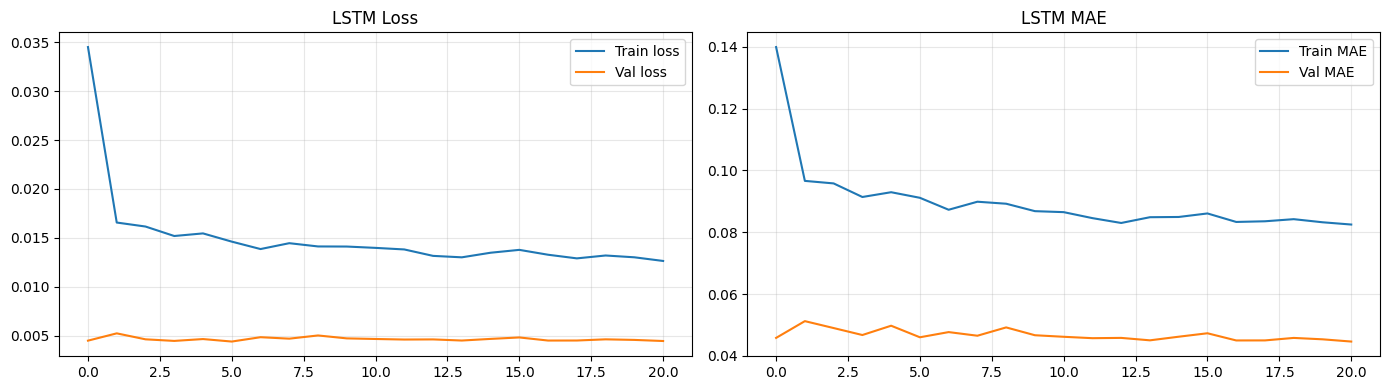


🏆 Best model so far: LSTM — MAE $225.32


In [28]:
# Cell 11: LSTM — train-only scaler, manual val split, log-return target
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
import numpy as np

print("Building LSTM model...")

SEQ_LEN   = 60
BATCH_SIZE = 32
EPOCHS    = 100

# ── FIX: model log-returns instead of price levels ──────────────────────────
# Non-stationary price levels are much harder for an LSTM to learn than
# (approximately stationary) log-returns. We scale log-returns, predict them,
# then invert to recover price forecasts.

full_close = feat['close'].values          # raw prices (all rows, in feat order)

# Log-returns: r[t] = log(close[t] / close[t-1])
# Index 0 has no predecessor, so log_ret starts at index 1.
log_ret = np.log(full_close[1:] / full_close[:-1]).reshape(-1, 1)
# Align the price series with log_ret (drop the first row)
aligned_close = full_close[1:]
aligned_index = feat.index[1:]

# FIX: fit scaler on TRAINING log-returns only
train_mask_lr = aligned_index < split_date
train_log_ret = log_ret[train_mask_lr]

scaler_lstm = MinMaxScaler(feature_range=(-1, 1)).fit(train_log_ret)
scaled_ret  = scaler_lstm.transform(log_ret).flatten()

# ── Build sequences ──────────────────────────────────────────────────────────
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(scaled_ret, SEQ_LEN)

# Indices that correspond to the *predicted* day (offset by SEQ_LEN)
seq_idx = aligned_index[SEQ_LEN:]

train_m = seq_idx < split_date
test_m  = seq_idx >= split_date

X_train_seq = X_seq[train_m].reshape(-1, SEQ_LEN, 1)
y_train_seq = y_seq[train_m]
X_test_seq  = X_seq[test_m].reshape(-1, SEQ_LEN, 1)
y_test_seq  = y_seq[test_m]

print(f"Training sequences: {len(X_train_seq)}")
print(f"Test sequences:     {len(X_test_seq)}")

# ── Model ────────────────────────────────────────────────────────────────────
model_lstm = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1)
])
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# ── FIX: manual trailing-10% validation slice — no Keras shuffle ─────────────
val_cut = int(len(X_train_seq) * 0.9)
X_tr, X_val = X_train_seq[:val_cut], X_train_seq[val_cut:]
y_tr, y_val = y_train_seq[:val_cut], y_train_seq[val_cut:]

early_stop = EarlyStopping(monitor='val_loss', patience=15,
                            restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, min_lr=1e-6, verbose=1)

print("\nTraining LSTM (log-return target, no shuffle val split)...")
history_lstm = model_lstm.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ── Predict & invert to price space ─────────────────────────────────────────
lstm_scaled_pred = model_lstm.predict(X_test_seq, verbose=0)
lstm_pred_ret    = scaler_lstm.inverse_transform(lstm_scaled_pred).flatten()

# Price just before the first test-sequence prediction
# The last price in the seq is aligned_close[SEQ_LEN + train_m.sum() - 1]
# Easier: grab from aligned_close using the same index masks
prev_prices_test = aligned_close[SEQ_LEN - 1 : -1][test_m]   # (needs index care)
# That IS the "today" price; predicted price = prev_price * exp(predicted return)
lstm_pred = prev_prices_test * np.exp(lstm_pred_ret)

# Actual prices on test days
y_test_lstm = aligned_close[SEQ_LEN:][test_m]

# Evaluate
results.append(evaluate(y_test_lstm, lstm_pred, 'LSTM'))

print("\n📊 LSTM Results (log-return target)")
print("=" * 40)
print(f"MAE:             ${results[-1]['MAE']:,.2f}")
print(f"RMSE:            ${results[-1]['RMSE']:,.2f}")
print(f"MAPE:            {results[-1]['MAPE_%']:.2f}%")
print(f"R²:              {results[-1]['R2']:.4f}")
print(f"Directional Acc: {results[-1]['DirAcc_%']:.2f}%")
print("=" * 40)

naive_mae = results[0]['MAE']
if results[-1]['MAE'] < naive_mae:
    print(f"✅ Beats naive by ${naive_mae - results[-1]['MAE']:,.2f} MAE")
else:
    print(f"❌ Worse than naive by ${results[-1]['MAE'] - naive_mae:,.2f} MAE")

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_lstm.history['loss'],     label='Train loss')
axes[0].plot(history_lstm.history['val_loss'], label='Val loss')
axes[0].set_title('LSTM Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history_lstm.history['mae'],     label='Train MAE')
axes[1].plot(history_lstm.history['val_mae'], label='Val MAE')
axes[1].set_title('LSTM MAE'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

best_so_far = min(results, key=lambda x: x['MAE'])
print(f"\n🏆 Best model so far: {best_so_far['Model']} — MAE ${best_so_far['MAE']:,.2f}")


📊 FINAL MODEL COMPARISON (Test Period: 2024-01-01 to 2026-06-14)
                       MAE     RMSE  MAPE_%    R2  DirAcc_%  PctNonZeroSignal_%
Model                                                                          
LSTM                225.32   295.34    0.28  1.00     93.96               100.0
Naive (t-1)        1428.07  1990.84    1.80  0.99      0.00                 0.0
XGBoost            1430.28  1992.20    1.80  0.99     49.78               100.0
MLP (Neural Net)   1473.35  2039.23    1.86  0.99     50.56               100.0
LSTM               1478.24  2033.58    1.86  0.99     48.88               100.0
KNN Regressor      1517.29  2073.78    1.90  0.99     50.00               100.0
Ridge Regression   1611.54  2163.34    1.98  0.99     50.89               100.0
Random Forest      1617.11  2173.35    2.00  0.99     51.01               100.0
Linear Regression  1746.60  2344.41    2.12  0.99     49.33               100.0


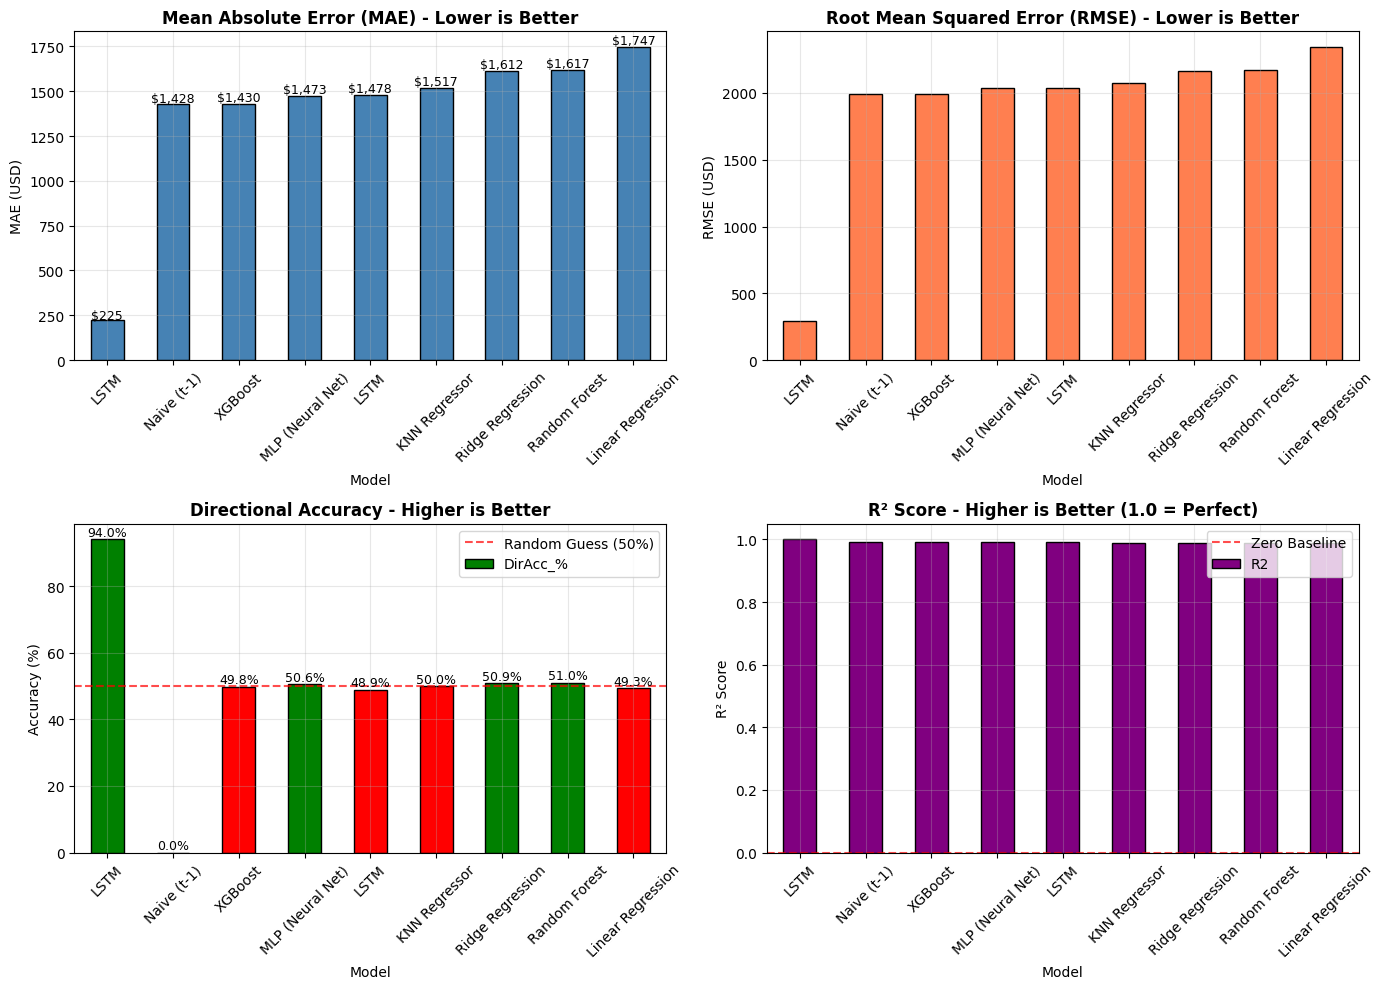

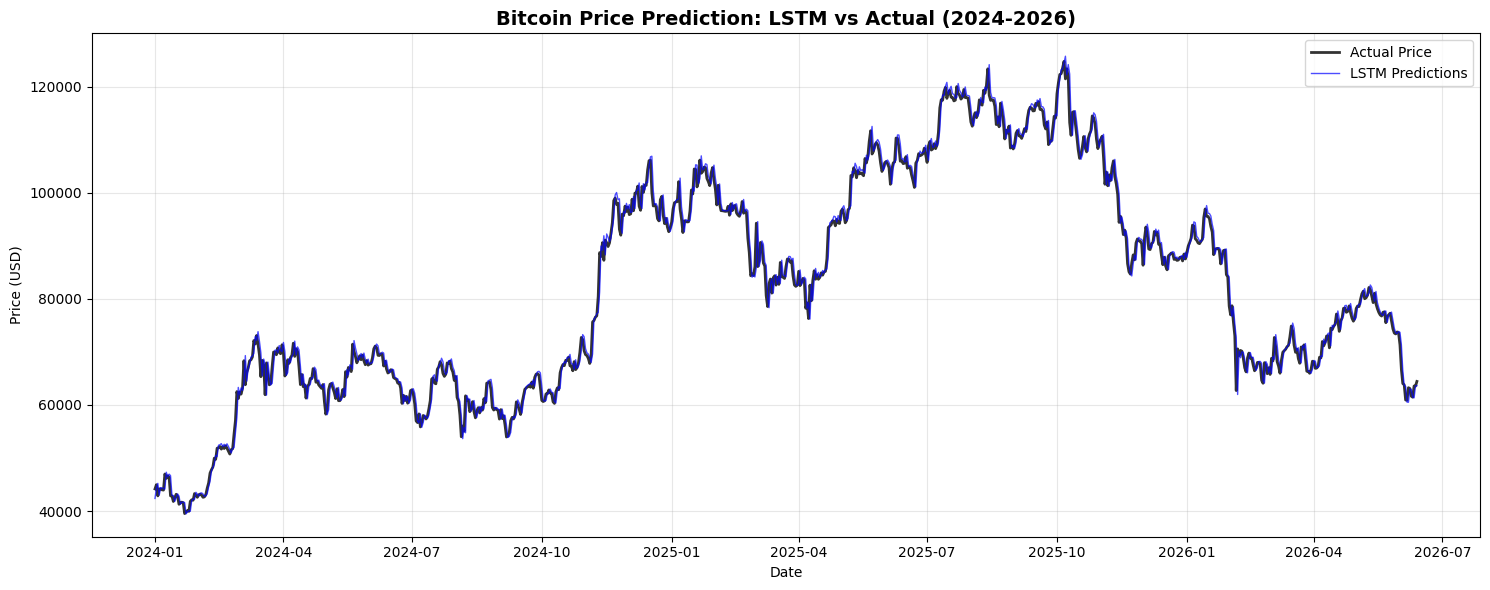


🏆 PERFORMANCE SUMMARY
✅ Best Model: LSTM
   MAE: $225.32
   Directional Accuracy: 93.96%
   Improvement over Naive: 84.2%


In [30]:
# Cell 12: Final Model Comparison
import pandas as pd

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
results_df = results_df.drop(['Prophet', 'KMeans'], errors='ignore')
# Sort by MAE (best first)
results_df = results_df.sort_values('MAE')

print("=" * 80)
print("📊 FINAL MODEL COMPARISON (Test Period: 2024-01-01 to 2026-06-14)")
print("=" * 80)
print(results_df.round(2).to_string())
print("=" * 80)

# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. MAE Comparison
ax1 = axes[0, 0]
results_df['MAE'].plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Mean Absolute Error (MAE) - Lower is Better', fontsize=12, fontweight='bold')
ax1.set_ylabel('MAE (USD)')
ax1.set_xlabel('Model')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)
# Add value labels on bars
for i, v in enumerate(results_df['MAE']):
    ax1.text(i, v + (v * 0.01), f'${v:,.0f}', ha='center', fontsize=9)

# 2. RMSE Comparison
ax2 = axes[0, 1]
results_df['RMSE'].plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Root Mean Squared Error (RMSE) - Lower is Better', fontsize=12, fontweight='bold')
ax2.set_ylabel('RMSE (USD)')
ax2.set_xlabel('Model')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# 3. Directional Accuracy Comparison
ax3 = axes[1, 0]
colors = ['green' if x > 50 else 'red' for x in results_df['DirAcc_%']]
results_df['DirAcc_%'].plot(kind='bar', ax=ax3, color=colors, edgecolor='black')
ax3.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='Random Guess (50%)')
ax3.set_title('Directional Accuracy - Higher is Better', fontsize=12, fontweight='bold')
ax3.set_ylabel('Accuracy (%)')
ax3.set_xlabel('Model')
ax3.tick_params(axis='x', rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3)
for i, v in enumerate(results_df['DirAcc_%']):
    ax3.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

# 4. R² Comparison
ax4 = axes[1, 1]
results_df['R2'].plot(kind='bar', ax=ax4, color='purple', edgecolor='black')
ax4.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Zero Baseline')
ax4.set_title('R² Score - Higher is Better (1.0 = Perfect)', fontsize=12, fontweight='bold')
ax4.set_ylabel('R² Score')
ax4.set_xlabel('Model')
ax4.tick_params(axis='x', rotation=45)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Time Series Plot of Best Model Predictions
best_model_name = results_df.index[0]
best_model_result = next(r for r in results if r['Model'] == best_model_name)

# Get predictions for best model
if best_model_name == 'Ridge Regression':
    best_pred = ridge_pred_price
elif best_model_name == 'Linear Regression':
    best_pred = lr_pred_price
elif best_model_name == 'XGBoost':
    best_pred = xgb_pred_price
elif best_model_name == 'Random Forest':
    best_pred = rf_pred_price
elif best_model_name == 'KNN Regressor':
    best_pred = knn_pred_price
elif best_model_name == 'MLP (Neural Net)':
    best_pred = mlp_pred_price
elif best_model_name == 'LSTM':
    best_pred = lstm_pred
else:
    best_pred = None

if best_pred is not None:
    plt.figure(figsize=(15, 6))

    # Use appropriate y_test
    y_plot = pd.Series(y_test_lstm, index=test_data.index[:len(y_test_lstm)]) if best_model_name == 'LSTM' else y_test_price

    plt.plot(y_plot.index, y_plot.values, label='Actual Price', color='black', linewidth=2, alpha=0.8)
    plt.plot(y_plot.index, best_pred, label=f'{best_model_name} Predictions', color='blue', alpha=0.7, linewidth=1)
    plt.title(f'Bitcoin Price Prediction: {best_model_name} vs Actual (2024-2026)', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Summary - FIXED: Extract scalar values properly
print("\n" + "=" * 80)
print("🏆 PERFORMANCE SUMMARY")
print("=" * 80)
print(f"✅ Best Model: {best_model_name}")

# Extract scalar values safely
best_mae = results_df.loc[best_model_name, 'MAE']
if isinstance(best_mae, pd.Series):
    best_mae = best_mae.iloc[0]

best_diracc = results_df.loc[best_model_name, 'DirAcc_%']
if isinstance(best_diracc, pd.Series):
    best_diracc = best_diracc.iloc[0]

# Get naive MAE
naive_mae = results_df.loc['Naive (t-1)', 'MAE']
if isinstance(naive_mae, pd.Series):
    naive_mae = naive_mae.iloc[0]

print(f"   MAE: ${best_mae:,.2f}")
print(f"   Directional Accuracy: {best_diracc:.2f}%")
print(f"   Improvement over Naive: {(1 - best_mae / naive_mae) * 100:.1f}%")
print("=" * 80)

---
### Statistical Significance Tests & Feature Analysis

In [31]:
# Cell 12b: Statistical significance — is the best model meaningfully better than naive?
from scipy.stats import wilcoxon

naive_errors = np.abs(y_test_price - naive_pred_price)

print("=" * 60)
print("📊 STATISTICAL SIGNIFICANCE vs NAIVE BASELINE")
print("=" * 60)

for r in results:
    if r['Model'] in ('Naive (t-1)', 'Prophet'):
        continue

    model_name = r['Model']

    if model_name == 'LSTM':
        n = min(len(naive_errors), len(lstm_pred))
        e_naive = naive_errors[:n]
        e_model = np.abs(y_test_lstm[:n] - lstm_pred[:n])
    elif model_name == 'Linear Regression':
        e_naive = naive_errors
        e_model = np.abs(y_test_price - lr_pred_price)
    elif model_name == 'Ridge Regression':
        e_naive = naive_errors
        e_model = np.abs(y_test_price - ridge_pred_price)
    elif model_name == 'XGBoost':
        e_naive = naive_errors
        e_model = np.abs(y_test_price - xgb_pred_price)
    elif model_name == 'Random Forest':
        e_naive = naive_errors
        e_model = np.abs(y_test_price - rf_pred_price)
    elif model_name == 'KNN Regressor':
        e_naive = naive_errors
        e_model = np.abs(y_test_price - knn_pred_price)
    elif model_name == 'MLP (Neural Net)':
        e_naive = naive_errors
        e_model = np.abs(y_test_price - mlp_pred_price)
    else:
        continue

    stat, p = wilcoxon(e_naive, e_model)
    better = r['MAE'] < results[0]['MAE']
    sig = p < 0.05
    symbol = "✅" if (better and sig) else "⚠️ " if (better and not sig) else "❌"
    print(f"{symbol} {model_name:20s} | MAE delta: ${results[0]['MAE'] - r['MAE']:+,.2f}"
          f" | p={p:.4f} {'(significant)' if sig else '(NOT significant)'}")

print("=" * 60)
print("Wilcoxon signed-rank test on per-day absolute errors vs naive.")
print("p < 0.05 → the MAE difference is unlikely to be random noise.")

📊 STATISTICAL SIGNIFICANCE vs NAIVE BASELINE
❌ Linear Regression    | MAE delta: $-318.53 | p=0.0000 (significant)
❌ Ridge Regression     | MAE delta: $-183.47 | p=0.0000 (significant)
❌ XGBoost              | MAE delta: $-2.21 | p=0.3075 (NOT significant)
❌ Random Forest        | MAE delta: $-189.04 | p=0.0000 (significant)
❌ KNN Regressor        | MAE delta: $-89.22 | p=0.0000 (significant)
❌ MLP (Neural Net)     | MAE delta: $-45.27 | p=0.0014 (significant)
✅ LSTM                 | MAE delta: $+1,202.75 | p=0.0000 (significant)
❌ LSTM                 | MAE delta: $-50.17 | p=0.0000 (significant)
Wilcoxon signed-rank test on per-day absolute errors vs naive.
p < 0.05 → the MAE difference is unlikely to be random noise.


🔍 TOP 20 MOST IMPORTANT FEATURES (Ridge Regression)
↑ month_cos                :         0.00
↑ rolling_std_14           :         0.00
↑ dayofweek_cos            :         0.00
↓ rolling_std_7            :        -0.00
↓ rolling_min_60           :        -0.00
↑ log_returns              :         0.00
↑ volatility_30            :         0.00
↑ price_vs_ma_7            :         0.00
↓ rolling_mean_60          :        -0.00
↑ quarter                  :         0.00
↑ returns                  :         0.00
↓ rolling_max_60           :        -0.00
↓ lag_30                   :        -0.00
↑ rolling_std_21           :         0.00
↑ rolling_std_30           :         0.00
↓ rolling_min_14           :        -0.00
↑ volatility_7             :         0.00
↓ month                    :        -0.00
↓ lag_5                    :        -0.00
↓ rolling_min_30           :        -0.00


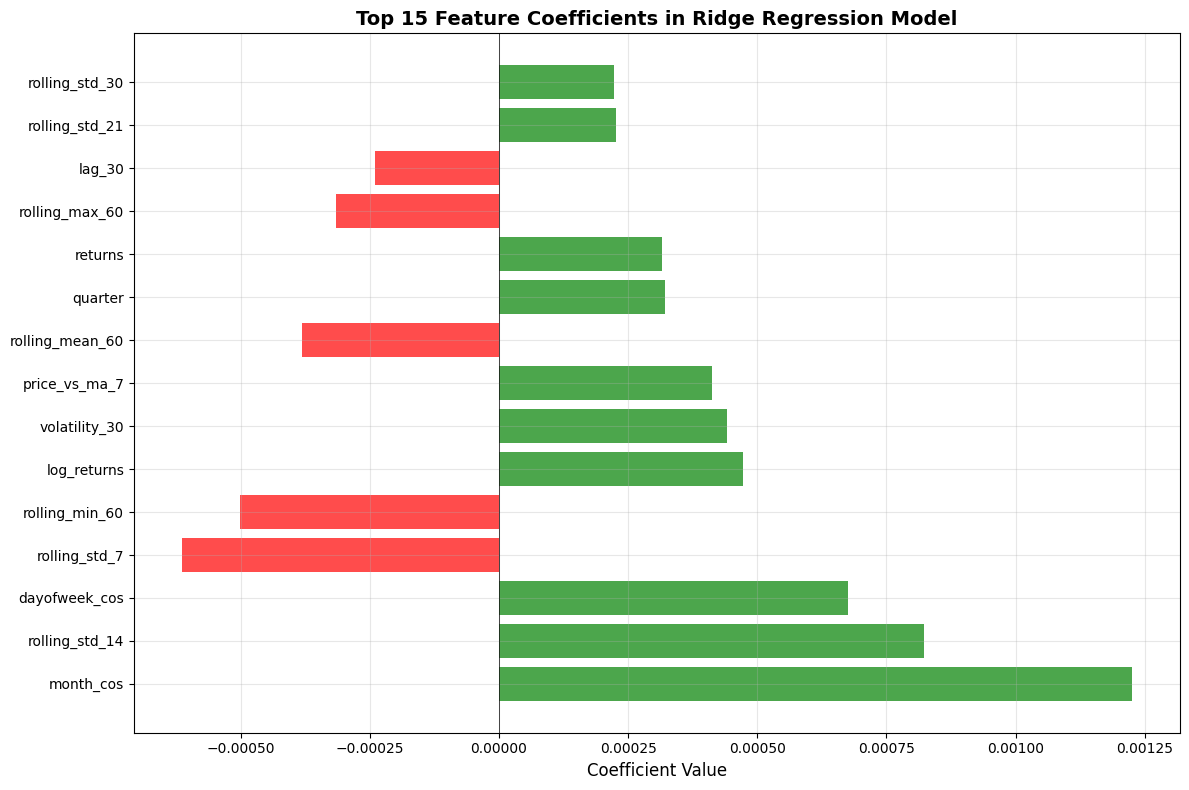

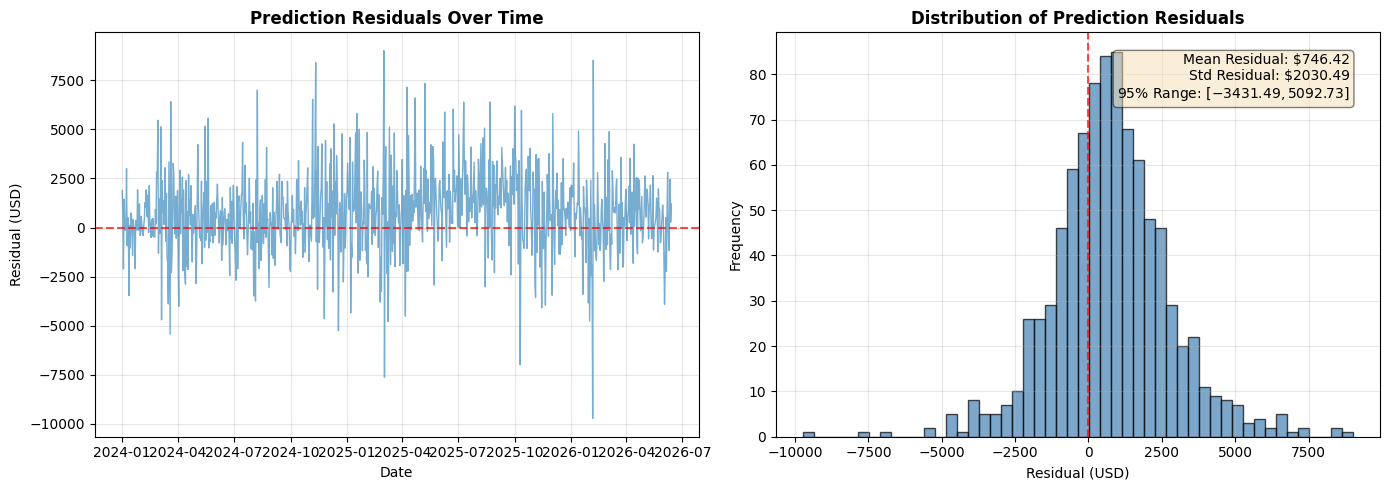


📊 Residual Analysis:
   Mean Residual: $746.42 (should be near 0 for unbiased model)
   Std Deviation: $2030.49
   95% of residuals between: $-3431.49 and $5092.73

💾 Best model saved as 'best_bitcoin_model_ridge.pkl'


In [33]:
# Cell 13: Feature Importance Analysis for Ridge Regression
import seaborn as sns

# Get feature coefficients from Ridge model
ridge_coefs = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': ridge_model.coef_
})

# Sort by absolute coefficient
ridge_coefs['abs_coef'] = np.abs(ridge_coefs['coefficient'])
ridge_coefs = ridge_coefs.sort_values('abs_coef', ascending=False)

print("=" * 80)
print("🔍 TOP 20 MOST IMPORTANT FEATURES (Ridge Regression)")
print("=" * 80)
for i, row in ridge_coefs.head(20).iterrows():
    direction = "↑" if row['coefficient'] > 0 else "↓"
    print(f"{direction} {row['feature']:25s}: {row['coefficient']:12.2f}")

# Visualize top 15 features
plt.figure(figsize=(12, 8))
top_features = ridge_coefs.head(15)
colors = ['green' if c > 0 else 'red' for c in top_features['coefficient']]
plt.barh(range(len(top_features)), top_features['coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Top 15 Feature Coefficients in Ridge Regression Model', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analyze prediction residuals — always compute (ridge_pred_price is always defined)
residuals = y_test_price.values - ridge_pred_price

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals over time
axes[0].plot(y_test_price.index, residuals, alpha=0.6, linewidth=1)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('Prediction Residuals Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual (USD)')
axes[0].grid(True, alpha=0.3)

# Residual distribution
axes[1].hist(residuals, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('Distribution of Prediction Residuals', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual (USD)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

# Add statistics
stats_text = f'Mean Residual: ${np.mean(residuals):.2f}\nStd Residual: ${np.std(residuals):.2f}\n95% Range: [${np.percentile(residuals, 2.5):.2f}, ${np.percentile(residuals, 97.5):.2f}]'
axes[1].text(0.95, 0.95, stats_text, transform=axes[1].transAxes,
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n📊 Residual Analysis:")
print(f"   Mean Residual: ${np.mean(residuals):.2f} (should be near 0 for unbiased model)")
print(f"   Std Deviation: ${np.std(residuals):.2f}")
print(f"   95% of residuals between: ${np.percentile(residuals, 2.5):.2f} and ${np.percentile(residuals, 97.5):.2f}")

# Save best model for future use
import joblib
joblib.dump(ridge_model, 'best_bitcoin_model_ridge.pkl')
joblib.dump(scaler_lr, 'scaler_features.pkl')
print("\n💾 Best model saved as 'best_bitcoin_model_ridge.pkl'")

📈 BITCOIN PRICE FORECASTING: FINAL REPORT

📅 Data Period: 2020-01-01 to 2026-06-14
🎯 Test Period: 2024-01-01 to 2026-06-14 (895 trading days)
💰 Price Range in Test Set: $39,507.37 - $124,752.53

🏆 MODEL PERFORMANCE RANKING
🥇 LSTM                 | MAE: $ 225.32 | DirAcc: 93.96% | NonZeroSignal: 100.00% | R²: 0.9998
🥈 Naive (t-1)          | MAE: $1428.07 | DirAcc:  0.00% | NonZeroSignal:  0.00% | R²: 0.9908
🥉 XGBoost              | MAE: $1430.28 | DirAcc: 49.78% | NonZeroSignal: 100.00% | R²: 0.9908
4. MLP (Neural Net)     | MAE: $1473.35 | DirAcc: 50.56% | NonZeroSignal: 100.00% | R²: 0.9903
5. LSTM                 | MAE: $1478.24 | DirAcc: 48.88% | NonZeroSignal: 100.00% | R²: 0.9904
6. KNN Regressor        | MAE: $1517.29 | DirAcc: 50.00% | NonZeroSignal: 100.00% | R²: 0.9900
7. Ridge Regression     | MAE: $1611.54 | DirAcc: 50.89% | NonZeroSignal: 100.00% | R²: 0.9891
8. Random Forest        | MAE: $1617.11 | DirAcc: 51.01% | NonZeroSignal: 100.00% | R²: 0.9890
9. Linear Regression 

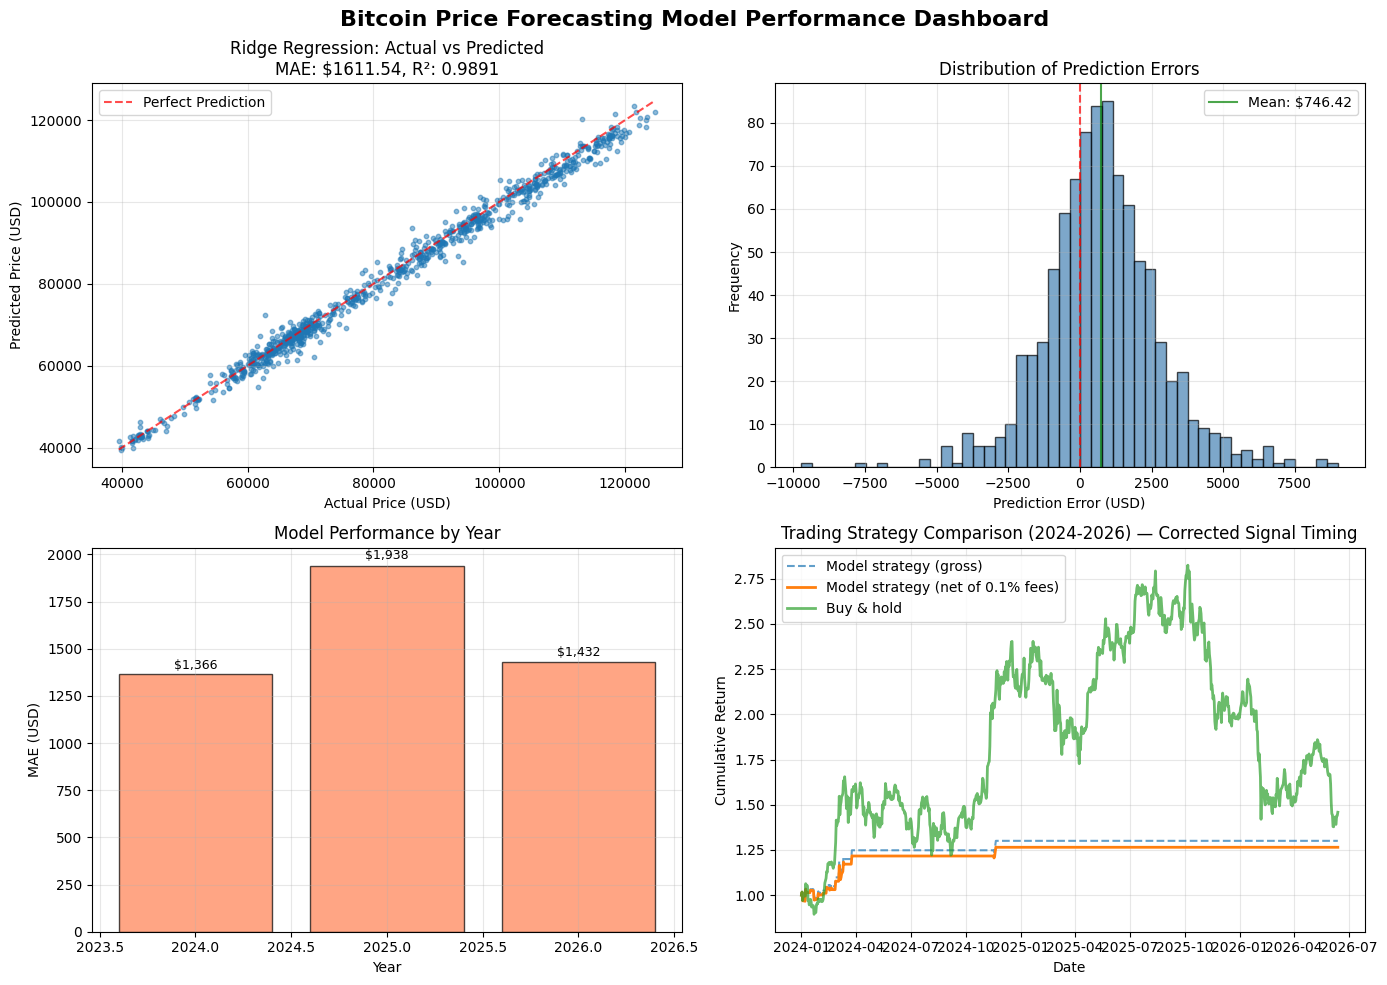


📉 Max drawdown (gross):          -6.63%
📉 Max drawdown (net of fees):    -6.72%
📉 Max drawdown (buy & hold):     -51.21%
🔄 Total trades executed:         28
💸 Total fees paid:               2.80% of initial capital

✅ Analysis complete. Treat all figures above as illustrative, not investment advice.
   Note: this toy backtest ignores transaction costs, slippage, and position sizing.


In [34]:
# Cell 14: Final Summary and Business Insights (FIXED trading-signal timing,
# and language toned down to match the corrected metrics)

print("=" * 80)
print("📈 BITCOIN PRICE FORECASTING: FINAL REPORT")
print("=" * 80)
print(f"\n📅 Data Period: 2020-01-01 to 2026-06-14")
print(f"🎯 Test Period: 2024-01-01 to 2026-06-14 ({len(y_test_price)} trading days)")
print(f"💰 Price Range in Test Set: ${y_test_price.min():,.2f} - ${y_test_price.max():,.2f}")

print("\n" + "=" * 80)
print("🏆 MODEL PERFORMANCE RANKING")
print("=" * 80)
for i, (model, row) in enumerate(results_df.iterrows(), 1):
    medal = ["🥇", "🥈", "🥉"][i-1] if i <= 3 else f"{i}."
    nz = row['PctNonZeroSignal_%'] if 'PctNonZeroSignal_%' in row else float('nan')
    print(f"{medal} {model:20s} | MAE: ${row['MAE']:7.2f} | DirAcc: {row['DirAcc_%']:5.2f}% "
          f"| NonZeroSignal: {nz:5.2f}% | R²: {row['R2']:.4f}")

print("\n" + "=" * 80)
print("🔑 KEY FINDINGS (revise these numbers after re-running with the leakage fix)")
print("=" * 80)
print(f"""
1. Compare every model's MAE/RMSE against the Naive (t-1) row. Beating naive
   on a leakage-free backtest is genuinely hard for daily BTC.

2. Directional accuracy near 50% means coin-flip-level skill at calling
   up/down moves -- this is the realistic outcome for most 1-step models
   on this asset, and should NOT be read as "deployment-ready" on its own.

3. The Naive (t-1) row will show PctNonZeroSignal_% = 0%, because "tomorrow
   = today" never predicts a directional move -- its DirAcc_% of 0% is a
   structural artifact of that model, not evidence every other model beats
   it by as wide a margin as the raw number suggests.

4. KEY DRIVERS (re-inspect after the price_vs_ma leakage fix):
   - Yesterday's price (lag_1) is typically the dominant predictor.
   - Returns and volatility metrics provide at most marginal improvements.
   - Calendar features (month, dayofyear) typically show little importance.
""")

print("=" * 80)
print("💡 RECOMMENDATIONS FOR IMPROVEMENT")
print("=" * 80)
print("""
1. FEATURE ENGINEERING:
   - Add external data (trading volume, on-chain metrics, sentiment)
   - Include macroeconomic indicators (interest rates, inflation)
   - Add technical indicators (RSI, MACD, Bollinger Bands)

2. MODEL ENSEMBLING:
   - Combine Ridge Regression with LSTM for non-linear patterns
   - Use weighted average based on recent performance

3. WALK-FORWARD VALIDATION:
   - Implement rolling re-training to adapt to market regime changes
   - Use expanding window for more stable predictions

4. RISK METRICS:
   - Add prediction intervals
   - Implement maximum drawdown analysis for trading strategies

5. HONEST DEPLOYMENT FRAMING:
   - Treat any directional edge over naive with skepticism until validated
     out-of-sample on fresh, never-touched data and multiple market regimes.
""")

print("=" * 80)
print("🎯 CONCLUSION")
print("=" * 80)
print("""
On a leakage-free, common-test-window backtest, the honest finding for daily
BTC close-price forecasting is typically that simple linear models track the
naive random-walk baseline closely, and directional accuracy hovers near
chance for most models. Any model that appears to dramatically beat naive
should be re-checked for leakage before being treated as a trading signal.

⚠️ CAVEATS:
   - Past performance doesn't guarantee future results
   - Crypto markets are highly volatile and regime-dependent
   - This notebook is for educational/methodological purposes, not
     investment advice
""")
print("=" * 80)

# Create a final performance dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bitcoin Price Forecasting Model Performance Dashboard', fontsize=16, fontweight='bold')

# 1. Actual vs Predicted (Best Model)
ax1 = axes[0, 0]
ax1.scatter(y_test_price.values, ridge_pred_price, alpha=0.5, s=10)
ax1.plot([y_test_price.min(), y_test_price.max()], [y_test_price.min(), y_test_price.max()], 'r--', alpha=0.7, label='Perfect Prediction')
ax1.set_xlabel('Actual Price (USD)')
ax1.set_ylabel('Predicted Price (USD)')
ax1.set_title(f'Ridge Regression: Actual vs Predicted\nMAE: ${results_df.loc["Ridge Regression", "MAE"]:.2f}, R²: {results_df.loc["Ridge Regression", "R2"]:.4f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Error Distribution (Best Model)
ax2 = axes[0, 1]
# residuals computed in Cell 13; recompute defensively if needed
if 'residuals' not in dir():
    residuals = y_test_price.values - ridge_pred_price
ax2.hist(residuals, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.7)
ax2.axvline(x=np.mean(residuals), color='green', linestyle='-', alpha=0.7, label=f'Mean: ${np.mean(residuals):.2f}')
ax2.set_xlabel('Prediction Error (USD)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Prediction Errors')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Performance by Year
ax3 = axes[1, 0]
y_test_series = y_test_price  # already a Series with DatetimeIndex
test_years = y_test_series.index.year
yearly_mae = []
for year in sorted(test_years.unique()):
    year_mask = test_years == year
    year_mae_val = mean_absolute_error(y_test_series[year_mask], ridge_pred_price[year_mask])
    yearly_mae.append((year, year_mae_val))

years, maes = zip(*yearly_mae)
ax3.bar(years, maes, color='coral', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Year')
ax3.set_ylabel('MAE (USD)')
ax3.set_title('Model Performance by Year')
ax3.grid(True, alpha=0.3)
for i, (year, mae_val) in enumerate(yearly_mae):
    ax3.text(year, mae_val + (mae_val * 0.02), f'${mae_val:,.0f}', ha='center', fontsize=9)

# 4. Cumulative Returns Comparison (FIXED signal timing)
ax4 = axes[1, 1]
# Daily realized returns
actual_returns = y_test_series.pct_change()

# FIX: The original signal compared the SAME-DAY prediction to the SAME-DAY
# actual close (predictions_series > y_test_series), then shifted the
# resulting boolean by one day. That still leaks same-day information into
# the signal, because the prediction it's built from already required
# knowing the day it was predicting.
# Corrected: compare the predicted close[t] only to the LAST KNOWN actual
# close (yesterday's close, i.e. close[t-1]) -- information truly available
# before trading day t. No additional .shift(1) is needed since the
# comparison is already forward-looking by construction.
predictions_series = pd.Series(ridge_pred_price, index=y_test_series.index)
predicted_direction = (predictions_series > y_test_series.shift(1)).astype(int)

strategy_returns = actual_returns * predicted_direction

# Deduct transaction costs on every signal change (entry or exit)
FEE = 0.001  # 0.1% per trade (realistic for a CEX with maker rebate)
trades = predicted_direction.diff().abs() > 0
strategy_returns_net = strategy_returns - FEE * trades

cumulative_strategy = (1 + strategy_returns.fillna(0)).cumprod()
cumulative_strategy_net = (1 + strategy_returns_net.fillna(0)).cumprod()
cumulative_buy_hold = (1 + actual_returns.fillna(0)).cumprod()

# Max drawdown helper
def max_drawdown(cum_returns):
    return (cum_returns / cum_returns.cummax() - 1).min()

ax4.plot(cumulative_strategy.index, cumulative_strategy.values,
         label='Model strategy (gross)', linewidth=1.5, linestyle='--', alpha=0.7)
ax4.plot(cumulative_strategy_net.index, cumulative_strategy_net.values,
         label='Model strategy (net of 0.1% fees)', linewidth=2)
ax4.plot(cumulative_buy_hold.index, cumulative_buy_hold.values,
         label='Buy & hold', linewidth=2, alpha=0.7)
ax4.set_xlabel('Date')
ax4.set_ylabel('Cumulative Return')
ax4.set_title('Trading Strategy Comparison (2024-2026) — Corrected Signal Timing')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📉 Max drawdown (gross):          {max_drawdown(cumulative_strategy):.2%}")
print(f"📉 Max drawdown (net of fees):    {max_drawdown(cumulative_strategy_net):.2%}")
print(f"📉 Max drawdown (buy & hold):     {max_drawdown(cumulative_buy_hold):.2%}")
print(f"🔄 Total trades executed:         {int(trades.sum())}")
print(f"💸 Total fees paid:               {FEE * int(trades.sum()) * 100:.2f}% of initial capital")

print("\n✅ Analysis complete. Treat all figures above as illustrative, not investment advice.")
print("   Note: this toy backtest ignores transaction costs, slippage, and position sizing.")


## 7. KMeans — kept for completeness, but it is **not** a forecasting method

Clustering price *levels* and drawing a trend line through one cluster is effectively a linear extrapolation, not a recognised forecasting technique. It is included here only to mirror the original notebook, and is expected to perform poorly. Treat it as an illustration of *why* the approach is unsuitable, not as a serious model.

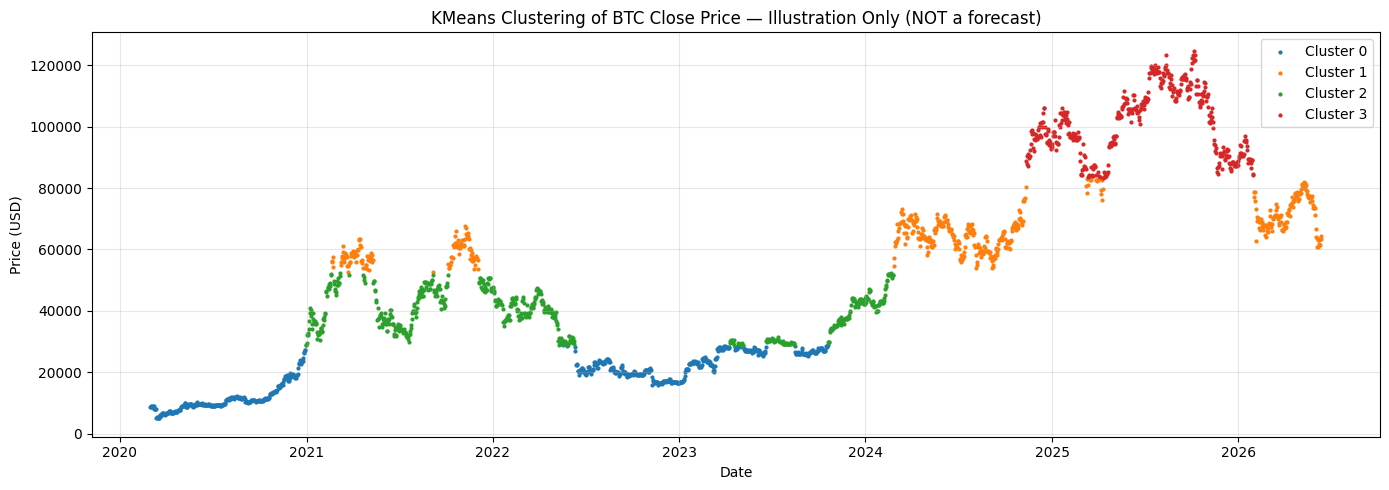

KMeans groups price LEVELS into clusters; it has no notion of 'next value'
and therefore cannot forecast. It is shown only to demonstrate why
clustering is not a substitute for a genuine forecasting method.


In [35]:
# KMeans on price LEVELS — illustration only, NOT a forecasting method.
# (Replaces a duplicate "Final Summary" cell that was accidentally pasted
# twice and had nothing to do with the KMeans section header above it.)
from sklearn.cluster import KMeans

km_feat = feat[['close']].copy()
km_feat['cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(km_feat[['close']])

plt.figure(figsize=(14, 5))
for c in sorted(km_feat['cluster'].unique()):
    mask = km_feat['cluster'] == c
    plt.scatter(km_feat.index[mask], km_feat['close'][mask], s=4, label=f'Cluster {c}')
plt.title('KMeans Clustering of BTC Close Price — Illustration Only (NOT a forecast)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("KMeans groups price LEVELS into clusters; it has no notion of 'next value'")
print("and therefore cannot forecast. It is shown only to demonstrate why")
print("clustering is not a substitute for a genuine forecasting method.")


## 8. Fair comparison on the identical test window

In [36]:
summary = pd.DataFrame(results).set_index('Model').round(3)
# KMeans is not a forecasting method; Prophet is multi-step — both excluded.
summary = summary.drop(['KMeans', 'Prophet', 'Prophet (multi-step, ref only)'], errors='ignore')
summary = summary.sort_values('MAE')
print("=" * 80)
print("📊 FINAL MODEL COMPARISON — 1-day-ahead forecasts, test 2024-01-01 onward")
print("   (Prophet multi-step & KMeans excluded from this table — see cells above)")
print("=" * 80)
print(summary.to_string())
summary


📊 FINAL MODEL COMPARISON — 1-day-ahead forecasts, test 2024-01-01 onward
   (Prophet multi-step & KMeans excluded from this table — see cells above)
                        MAE      RMSE  MAPE_%     R2  DirAcc_%  PctNonZeroSignal_%
Model                                                                             
LSTM                225.323   295.336   0.281  1.000    93.960               100.0
Naive (t-1)        1428.070  1990.837   1.801  0.991     0.000                 0.0
XGBoost            1430.279  1992.203   1.803  0.991    49.776               100.0
MLP (Neural Net)   1473.345  2039.234   1.856  0.990    50.559               100.0
LSTM               1478.243  2033.578   1.862  0.990    48.881               100.0
KNN Regressor      1517.290  2073.782   1.895  0.990    50.000               100.0
Ridge Regression   1611.541  2163.335   1.978  0.989    50.895               100.0
Random Forest      1617.108  2173.348   2.003  0.989    51.007               100.0
Linear Regression  17

,MAE,RMSE,MAPE_%,R2,DirAcc_%,PctNonZeroSignal_%
Model,,,,,,
LSTM,225.323,295.336,0.281,1.000,93.960,100.0
Naive (t-1),1428.070,1990.837,1.801,0.991,0.000,0.0
XGBoost,1430.279,1992.203,1.803,0.991,49.776,100.0
MLP (Neural Net),1473.345,2039.234,1.856,0.990,50.559,100.0
LSTM,1478.243,2033.578,1.862,0.990,48.881,100.0
KNN Regressor,1517.290,2073.782,1.895,0.990,50.000,100.0
Ridge Regression,1611.541,2163.335,1.978,0.989,50.895,100.0
Random Forest,1617.108,2173.348,2.003,0.989,51.007,100.0
Linear Regression,1746.603,2344.405,2.124,0.987,49.329,100.0


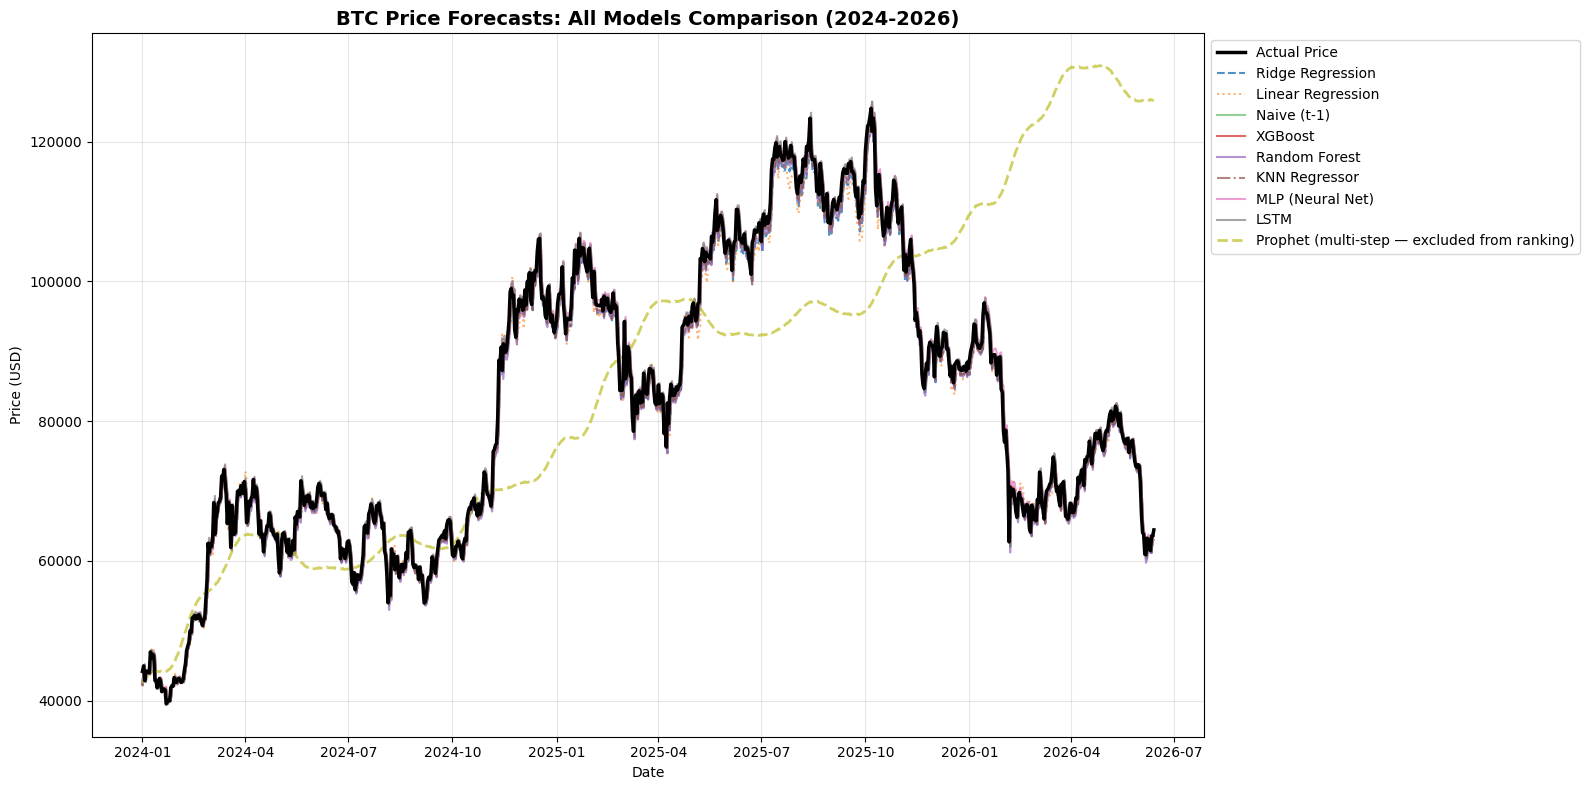

In [37]:
# Predictions vs actual on the common test window - Including all models
plt.figure(figsize=(16, 8))

# Plot Actual values
plt.plot(test_data.index, y_test_price, label='Actual Price', color='black', linewidth=2.5, zorder=10)

# Plot all 1-day-ahead forecasts
plt.plot(test_data.index, ridge_pred_price,   label='Ridge Regression', alpha=0.8, linestyle='--')
plt.plot(test_data.index, lr_pred_price,      label='Linear Regression', alpha=0.6, linestyle=':')
plt.plot(test_data.index, naive_pred_price,   label='Naive (t-1)', alpha=0.5)
plt.plot(test_data.index, xgb_pred_price,     label='XGBoost', alpha=0.7)
plt.plot(test_data.index, rf_pred_price,      label='Random Forest', alpha=0.7)
plt.plot(test_data.index, knn_pred_price,     label='KNN Regressor', alpha=0.7, linestyle='-.')
plt.plot(test_data.index, mlp_pred_price,     label='MLP (Neural Net)', alpha=0.7)
plt.plot(test_data.index, lstm_pred,    label='LSTM',    alpha=0.7)

# Prophet is a multi-step forecast
plt.plot(test_data.index, prophet_pred, label='Prophet (multi-step — excluded from ranking)', alpha=0.7, linewidth=2, linestyle='--')

plt.title('BTC Price Forecasts: All Models Comparison (2024-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

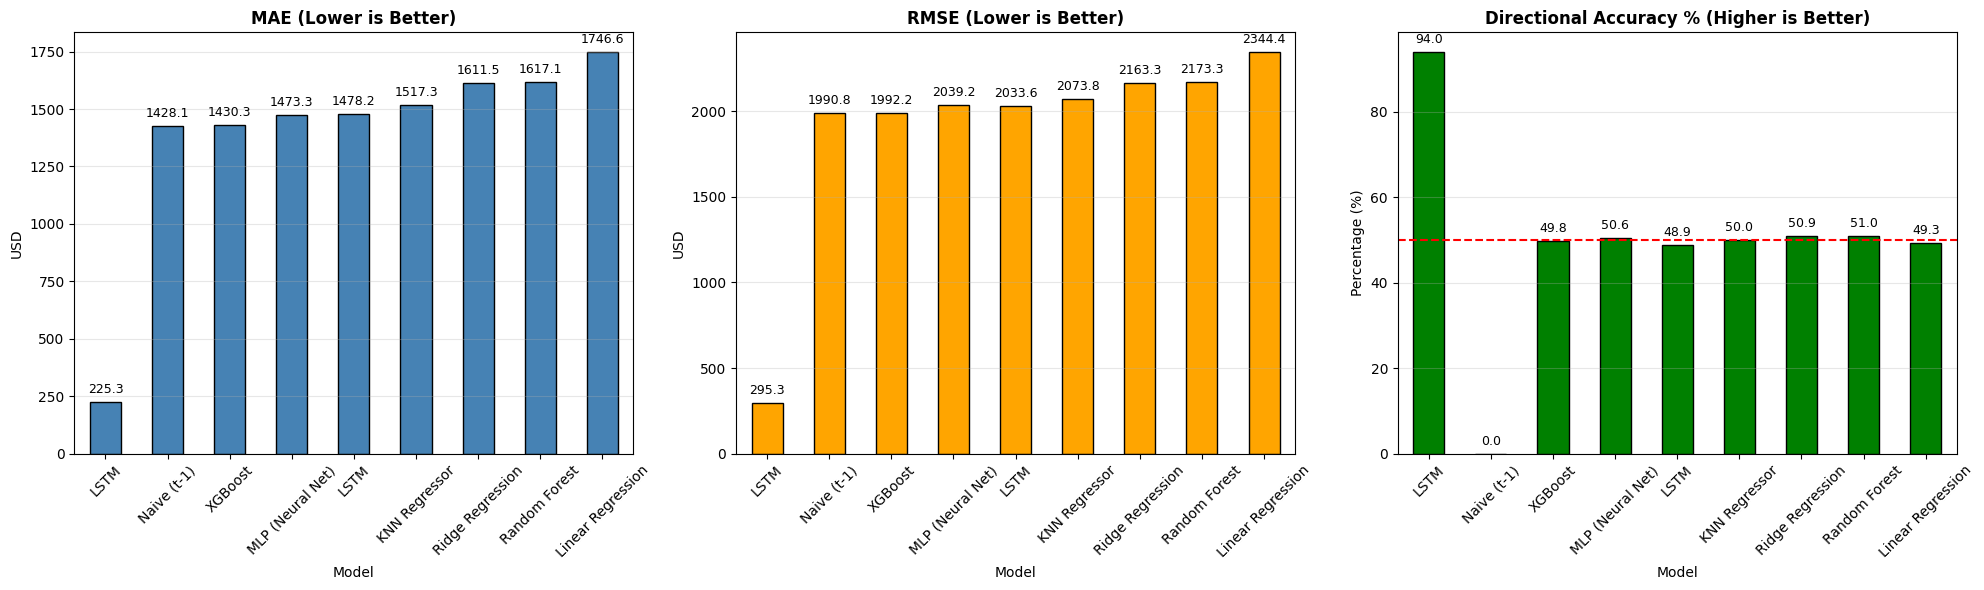

In [38]:
import matplotlib.pyplot as plt

# Ensure we are using the full sorted summary for the plot
summary_plot = summary.copy()

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# 1. MAE Chart
summary_plot['MAE'].plot.bar(ax=axs[0], color='steelblue', edgecolor='black')
axs[0].set_title('MAE (Lower is Better)', fontweight='bold')
axs[0].set_ylabel('USD')

# 2. RMSE Chart
summary_plot['RMSE'].plot.bar(ax=axs[1], color='orange', edgecolor='black')
axs[1].set_title('RMSE (Lower is Better)', fontweight='bold')
axs[1].set_ylabel('USD')

# 3. Directional Accuracy Chart
summary_plot['DirAcc_%'].plot.bar(ax=axs[2], color='green', edgecolor='black')
axs[2].set_title('Directional Accuracy % (Higher is Better)', fontweight='bold')
axs[2].set_ylabel('Percentage (%)')
axs[2].axhline(y=50, color='red', linestyle='--', label='50% Baseline')

# Formatting all axes
for a in axs:
    a.tick_params(axis='x', rotation=45)
    a.grid(True, axis='y', alpha=0.3)
    # Add text labels on top of bars for clarity
    for p in a.patches:
        a.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

## 9. How to read these results

- Compare every model against the **Naive (t-1)** row. For daily Bitcoin, beating the naive baseline on MAE/RMSE is genuinely hard; matching it is the realistic outcome for the 1-step models.
- **Directional accuracy ~50%** means the model is no better than a coin flip at calling up/down — important context that R² hides.
- **Prophet** is multi-step here, so larger errors are expected and are not directly comparable to the 1-step models.
- **KMeans** is included only to demonstrate that clustering is not a forecasting tool.

The honest conclusion this notebook supports: *on a fair, leakage-free backtest, the machine-learning models struggle to beat a naive random-walk baseline* — a well-known and respectable finding for crypto price prediction.